In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
import re
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.optimize import root_scalar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import gaussian_kde
from math import sqrt, pi


### 데이터 불러오기

수요 공급 곡선 데이터 

In [18]:
files = glob.glob("filteredcurve_202507*.csv")
df_list = []
for fn in files:
    temp = pd.read_csv(fn, encoding="utf-8-sig")

    # 파일명에서 날짜 추출
    date_str = fn.split("_")[-1].split(".")[0]   # "20250720"
    temp["Date"] = pd.to_datetime(date_str, format="%Y%m%d")

    # 공급곡선의 Period → Hour 변환 (1~24 → 0~23)
    temp = temp.dropna(subset=["Time Period"])
    temp["Hour"] = temp["Time Period"].astype(int)

    # Datetime 만들기 (같은 포맷: "20250720 0")
    temp["Datetime"] = temp["Date"].dt.strftime("%Y%m%d") + " " + temp["Hour"].astype(str)

    df_list.append(temp)

df_supply = pd.concat(df_list, ignore_index=True)

print(df_supply[["Date", "Hour", "Datetime"]].head())

        Date  Hour    Datetime
0 2025-07-01     1  20250701 1
1 2025-07-01     1  20250701 1
2 2025-07-01     1  20250701 1
3 2025-07-01     1  20250701 1
4 2025-07-01     1  20250701 1


날씨 데이터: df_weather

In [19]:
df_weather = pd.read_csv("weather_transformed.csv")

df_weather["T"] = pd.to_numeric(df_weather["T"], errors="coerce")
df_weather["ff"] = pd.to_numeric(df_weather["ff"], errors="coerce")

# Hour → 숫자로 변환 (변환 불가는 NaN)
df_weather["Hour"] = pd.to_numeric(df_weather["Hour"], errors="coerce")

# NaN 값 제거
df_weather = df_weather.dropna(subset=["Hour"])

# int 변환
df_weather["Hour"] = df_weather["Hour"].astype(int)

# Date를 datetime으로 변환
df_weather["Date"] = pd.to_datetime(df_weather["Date"], errors="coerce")

# Datetime 생성: "20250731 13"
df_weather["Datetime"] = df_weather["Date"].dt.strftime("%Y%m%d") + " " + df_weather["Hour"].astype(str)

df_weather["Weekday"] = df_weather["Date"].dt.weekday  

# 주말 여부 (토=5, 일=6 → True)
df_weather["IsWeekend"] = df_weather["Weekday"].isin([5, 6])

print(df_weather[["Date", "Hour", "Datetime", "Weekday", "IsWeekend"]].head(100))

          Date  Hour     Datetime  Weekday  IsWeekend
1   2025-07-31    24  20250731 24        3      False
2   2025-07-31    23  20250731 23        3      False
3   2025-07-31    22  20250731 22        3      False
4   2025-07-31    21  20250731 21        3      False
5   2025-07-31    20  20250731 20        3      False
..         ...   ...          ...      ...        ...
97  2025-07-28     1   20250728 1        0      False
98  2025-07-27    24  20250727 24        6       True
99  2025-07-27    23  20250727 23        6       True
100 2025-07-27    22  20250727 22        6       True
101 2025-07-27    21  20250727 21        6       True

[100 rows x 5 columns]


C:\Users\symply_jina\AppData\Local\Temp\ipykernel_42032\2741458697.py:16: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_weather["Date"] = pd.to_datetime(df_weather["Date"], errors="coerce")


예측 수요 데이터: df_forecast

In [20]:
file_path = "demandforecast0903.xls"

# 1. HTML로 읽기 시도
try:
    dfs = pd.read_html(file_path)
    read_type = "html"
    df_forecast = dfs[0]
except Exception as e_html:
    # 2. CSV로 읽기 시도
    try:
        df_forecast = pd.read_csv(file_path)
        read_type = "csv"
    except Exception as e_csv:
        df_forecast = None
        read_type = f"fail: {e_csv}"

(read_type, df_forecast.head() if df_forecast is not None else None)

# 1. 컬럼 정리 (첫 행이 컬럼명이면 이 과정 필요)
df_forecast.columns = df_forecast.iloc[0]   # 첫 번째 행을 컬럼명으로
df_forecast = df_forecast.drop(0).reset_index(drop=True)

# 2. datetime 처리
df_forecast["datetime"] = pd.to_datetime(df_forecast["datetime"], errors="coerce")

# 3. Date와 Hour 분리
df_forecast["Date"] = df_forecast["datetime"].dt.strftime("%Y%m%d")   # YYYYMMDD 문자열
df_forecast["Hour"] = df_forecast["datetime"].dt.hour + 1             # 0~23 → 1~24

# 4. Datetime: "20250701 1" 형태로
df_forecast["Datetime"] = df_forecast["Date"] + " " + df_forecast["Hour"].astype(str)

# 요일 (0=월, 6=일)
df_forecast["Weekday"] = df_forecast["datetime"].dt.weekday
# df_forecast["Weekday"] = df_forecast["Date"].dt.weekday  

# 주말 여부 (토=5, 일=6 → True)
df_forecast["IsWeekend"] = df_forecast["Weekday"].isin([5, 6])

# 5. value를 숫자로 변환
df_forecast["value"] = pd.to_numeric(df_forecast["value"], errors="coerce")

# 확인
print(df_forecast[["Date", "Hour", "Datetime", "value", "Weekday"]].head(10))
print(df_forecast.dtypes)



0      Date  Hour     Datetime    value  Weekday
0  20250630    18  20250630 18  37552.5        0
1  20250630    19  20250630 19  37571.8        0
2  20250630    20  20250630 20  37861.0        0
3  20250630    21  20250630 21  37543.0        0
4  20250630    22  20250630 22  37057.8        0
5  20250630    23  20250630 23  35464.8        0
6  20250630    24  20250630 24  32630.3        0
7  20250701     1   20250701 1  31178.3        1
8  20250701     2   20250701 2  29220.3        1
9  20250701     3   20250701 3  27816.3        1
0
id                              object
name                            object
geoid                           object
geoname                         object
value                          float64
datetime     datetime64[ns, UTC+02:00]
Date                            object
Hour                             int32
Datetime                        object
Weekday                          int32
IsWeekend                         bool
dtype: object


# 클러스터링

### 주말유무 + 온도

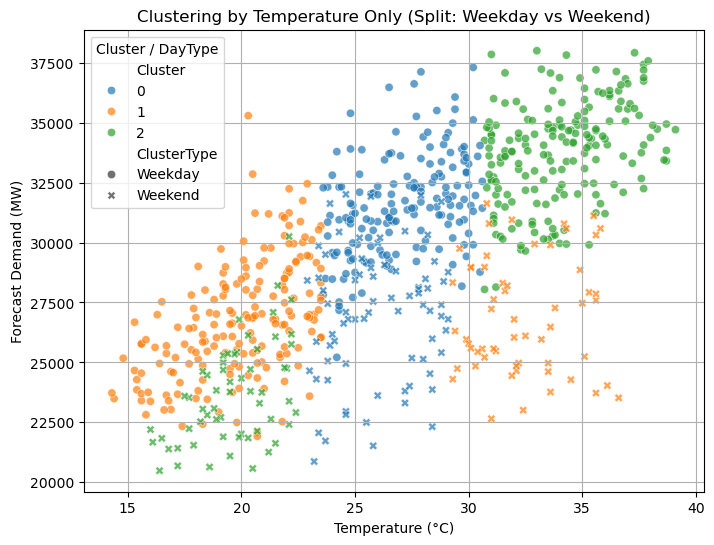

     Datetime     T    value  IsWeekend  Cluster
0  20250701 1  24.9  31178.3      False        0
1  20250701 2  25.4  29220.3      False        0
2  20250701 3  23.6  27816.3      False        0
3  20250701 4  23.2  26997.3      False        1
4  20250701 5  21.8  26562.8      False        1


In [71]:
# 결과를 저장할 리스트
results = []
df_merged = pd.merge(
    df_forecast[["Datetime", "value", "Weekday", "IsWeekend"]],
    df_weather[["Datetime", "T"]],
    on="Datetime", how="inner"
)

# 평일/주말 그룹 나눠서 반복
for weekend_flag, sub in df_merged.groupby("IsWeekend"):
    if sub.empty:
        continue
    
    # 스케일링 (온도만)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(sub[["T"]])   # <- 여기서 value 제거
    
    # KMeans (예: 3개 클러스터)
    kmeans = KMeans(n_clusters=3, random_state=42)
    labels = kmeans.fit_predict(scaled)
    
    # 결과 저장
    sub = sub.copy()
    sub["Cluster"] = labels
    sub["ClusterType"] = "Weekend" if weekend_flag else "Weekday"
    results.append(sub)

# 합치기
df_clustered = pd.concat(results, ignore_index=True)

# ===== 시각화 =====
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_clustered, x="T", y="value",    # y축은 value를 그대로 쓰면 예측수요와 클러스터의 관계를 볼 수 있음
    hue="Cluster", style="ClusterType", palette="tab10", alpha=0.7
)
plt.xlabel("Temperature (°C)")
plt.ylabel("Forecast Demand (MW)")
plt.title("Clustering by Temperature Only (Split: Weekday vs Weekend)")
plt.legend(title="Cluster / DayType")
plt.grid(True)
plt.show()

# 확인
print(df_clustered[["Datetime", "T", "value", "IsWeekend", "Cluster"]].head())


### 주말유무 + (온도, 예측수요) 에 대하여 클러스터링

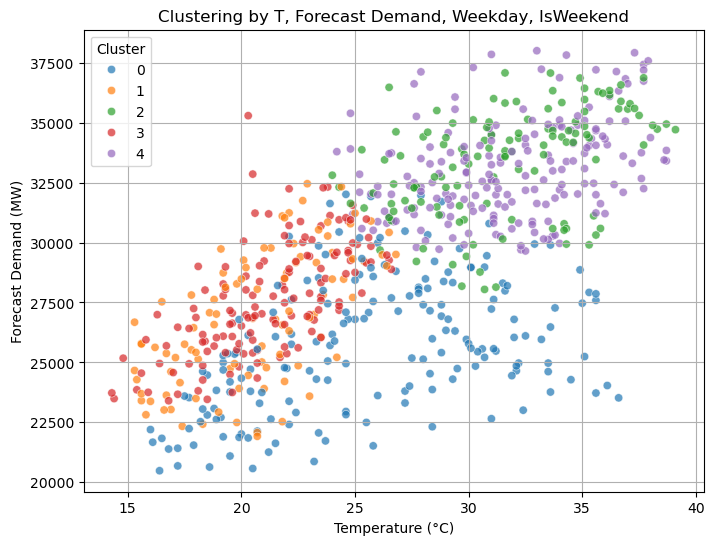

     Datetime     T    value  Weekday  IsWeekend  Cluster
0  20250701 1  24.9  31178.3        1      False        4
1  20250701 2  25.4  29220.3        1      False        1
2  20250701 3  23.6  27816.3        1      False        1
3  20250701 4  23.2  26997.3        1      False        1
4  20250701 5  21.8  26562.8        1      False        1


In [ ]:
# # ====== Merge (Datetime 기준) ======
# df_merged = pd.merge(
#     df_forecast[["Datetime", "value", "Weekday", "IsWeekend"]],
#     df_weather[["Datetime", "T"]],
#     on="Datetime", how="inner"
# )

# # ====== 클러스터링 Feature ======
# # 원핫 인코딩
# # features = pd.get_dummies(df_merged[["T", "value", "Weekday"]], columns=["Weekday"])

# # # 스케일링 (T, value만)
# # scaler = StandardScaler()
# # X_scaled = scaler.fit_transform(features)

# # # 클러스터링
# # kmeans = KMeans(n_clusters=5, random_state=42)
# # df_merged["Cluster"] = kmeans.fit_predict(X_scaled)
# # 스케일링할 부분만 선택
# scaler = StandardScaler()
# scaled = scaler.fit_transform(df_merged[["T","value"]])

# # Weekday는 그대로 추가
# X_scaled = np.column_stack([scaled, df_merged["Weekday"].values])

# # KMeans
# kmeans = KMeans(n_clusters=5, random_state=42)
# df_merged["Cluster"] = kmeans.fit_predict(X_scaled)

# # 시각화
# plt.figure(figsize=(8,6))
# sns.scatterplot(data=df_merged, x="T", y="value", hue="Cluster", palette="tab10", alpha=0.7)
# plt.xlabel("Temperature (°C)")
# plt.ylabel("Forecast Demand (MW)")
# plt.title("Clustering by T, Forecast Demand, Weekday, IsWeekend")
# plt.legend(title="Cluster")
# plt.grid(True)
# plt.show()

# # 결과 확인
# print(df_merged[["Datetime", "T", "value", "Weekday", "Cluster"]].head())


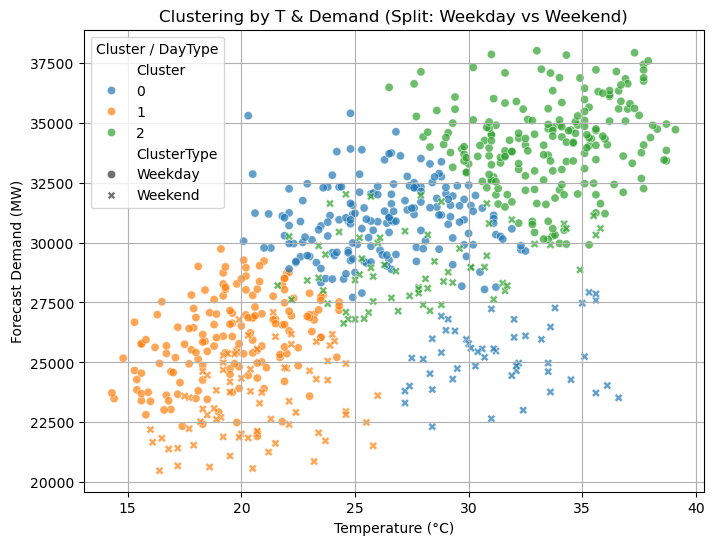

     Datetime     T    value  IsWeekend  Cluster
0  20250701 1  24.9  31178.3      False        0
1  20250701 2  25.4  29220.3      False        0
2  20250701 3  23.6  27816.3      False        1
3  20250701 4  23.2  26997.3      False        1
4  20250701 5  21.8  26562.8      False        1


In [73]:
# 결과를 저장할 리스트
results = []
df_merged = pd.merge(
    df_forecast[["Datetime", "value", "Weekday", "IsWeekend"]],
    df_weather[["Datetime", "T"]],
    on="Datetime", how="inner"
)
# 평일/주말 그룹 나눠서 반복
for weekend_flag, sub in df_merged.groupby("IsWeekend"):
    if sub.empty:
        continue
    
    # 스케일링 (T, value만)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(sub[["T", "value"]])
    
    # KMeans (예: 3개 클러스터)
    kmeans = KMeans(n_clusters=3, random_state=42)
    labels = kmeans.fit_predict(scaled)
    
    # 결과 저장
    sub = sub.copy()
    sub["Cluster"] = labels
    sub["ClusterType"] = "Weekend" if weekend_flag else "Weekday"
    results.append(sub)

# 합치기
df_clustered = pd.concat(results, ignore_index=True)

# ===== 시각화 =====
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_clustered, x="T", y="value",
    hue="Cluster", style="ClusterType", palette="tab10", alpha=0.7
)
plt.xlabel("Temperature (°C)")
plt.ylabel("Forecast Demand (MW)")
plt.title("Clustering by T & Demand (Split: Weekday vs Weekend)")
plt.legend(title="Cluster / DayType")
plt.grid(True)
plt.show()

# 확인
print(df_clustered[["Datetime", "T", "value", "IsWeekend", "Cluster"]].head())


### 클러스터링 확인

주말

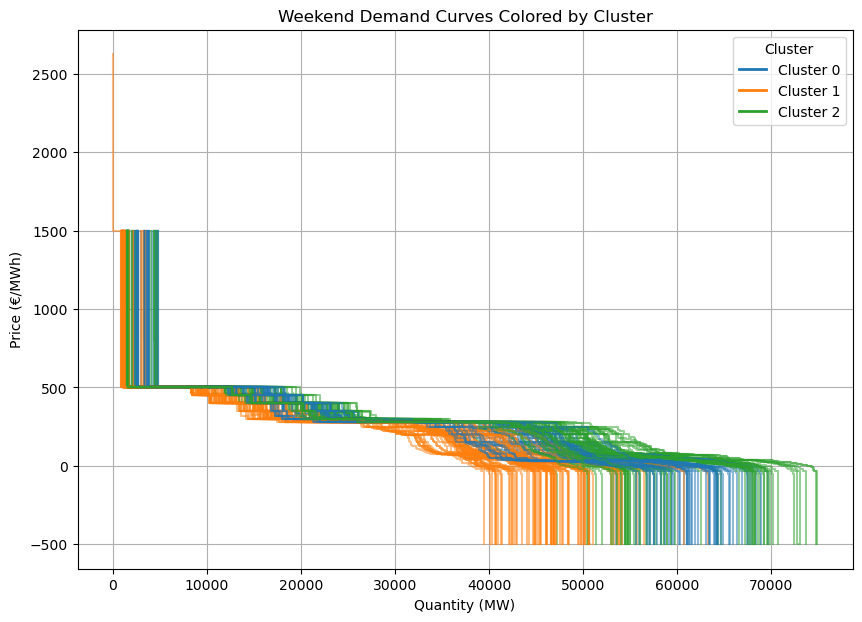

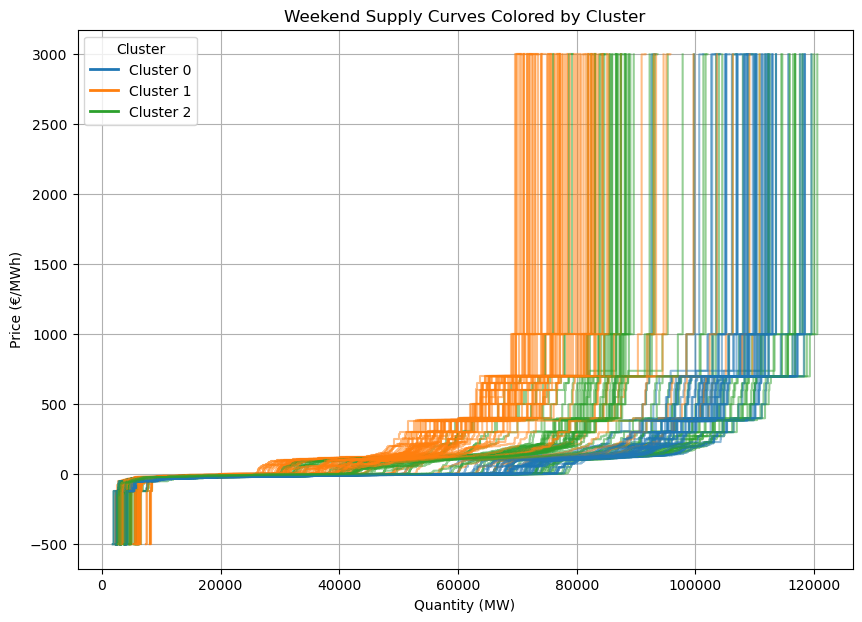

In [74]:
# 1. 요일/주말 여부 붙이기 (df_supply 기준)
df_supply["Weekday"] = df_supply["Date"].dt.weekday
df_supply["IsWeekend"] = df_supply["Weekday"].isin([5,6])

# 2. 주말 데이터만 선택
df_weekend = df_supply[df_supply["IsWeekend"]]

# 3. Cluster 라벨 붙이기 (Datetime 기준 merge)
df_weekend = df_weekend.merge(
    df_clustered[["Datetime","Cluster"]],
    on="Datetime", how="left"
)

# 4. 색상 팔레트 (클러스터 개수만큼)
clusters = sorted(df_weekend["Cluster"].dropna().unique())
palette = dict(zip(clusters, sns.color_palette("tab10", len(clusters))))

# ========================
# (A) 주말 수요곡선
# ========================
plt.figure(figsize=(10,7))

for dt in df_weekend["Datetime"].unique():
    sub = df_weekend[df_weekend["Datetime"]==dt]
    cluster = sub["Cluster"].iloc[0]   # 해당 시간의 클러스터
    
    # 수요곡선만 선택
    dem = sub[sub["GC"]=="C"]
    if dem.empty:
        continue
    
    d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]
    
    # 수요곡선: 클러스터 색상
    plt.step(d_agg["Cumul"], d_agg["Price"],
             where="post", color=palette[cluster], alpha=0.5)

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Weekend Demand Curves Colored by Cluster")
plt.grid(True)

# 범례
handles = [plt.Line2D([0],[0], color=palette[c], lw=2, label=f"Cluster {c}") for c in clusters]
plt.legend(handles=handles, title="Cluster")
plt.show()


# ========================
# (B) 주말 공급곡선
# ========================
plt.figure(figsize=(10,7))

for dt in df_weekend["Datetime"].unique():
    sub = df_weekend[df_weekend["Datetime"]==dt]
    cluster = sub["Cluster"].iloc[0]   # 해당 시간의 클러스터
    
    # 공급곡선만 선택
    sup = sub[sub["GC"]=="V"]
    if sup.empty:
        continue
    
    s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    s_agg["Cumul"] = s_agg["Amount"].cumsum()
    
    # 공급곡선: 클러스터 색상
    plt.step(s_agg["Cumul"], s_agg["Price"],
             where="post", color=palette[cluster], alpha=0.5)

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Weekend Supply Curves Colored by Cluster")
plt.grid(True)

# 범례
handles = [plt.Line2D([0],[0], color=palette[c], lw=2, label=f"Cluster {c}") for c in clusters]
plt.legend(handles=handles, title="Cluster")
plt.show()


평일

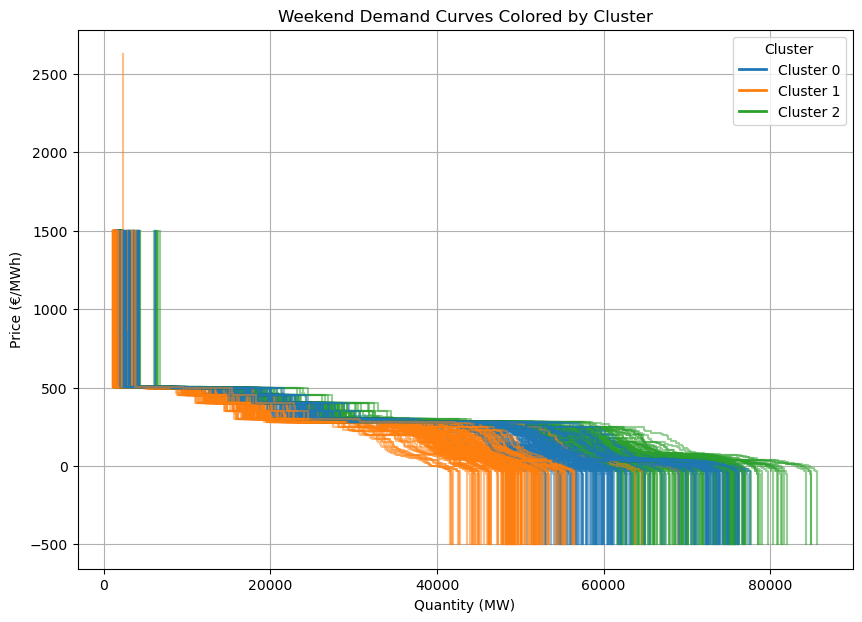

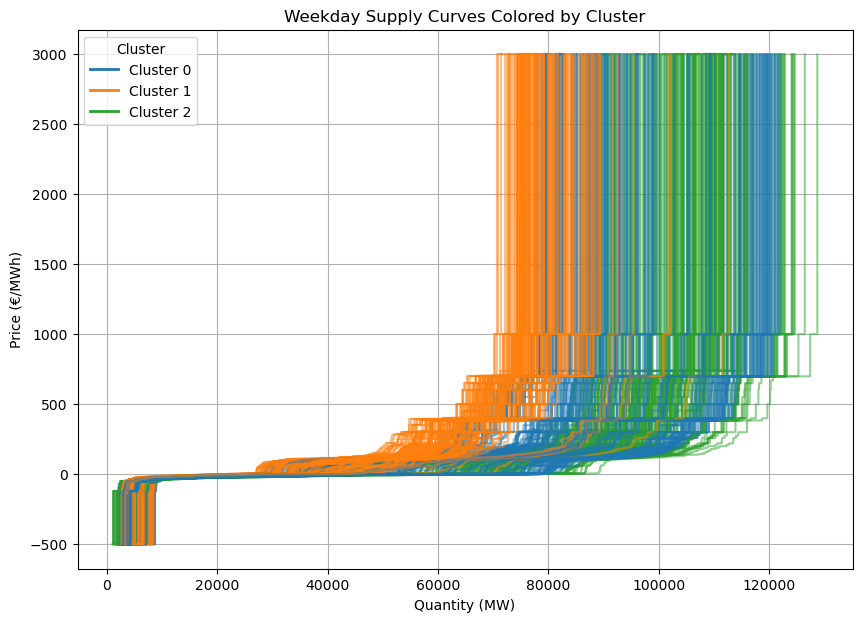

In [75]:
# 1. 요일/주말 여부 붙이기 (df_supply 기준)
df_supply["Weekday"] = df_supply["Date"].dt.weekday
df_supply["IsWeekend"] = df_supply["Weekday"].isin([5,6])

# 2. 주말 데이터만 선택
df_weekday = df_supply[~df_supply["IsWeekend"]]

# 3. Cluster 라벨 붙이기 (Datetime 기준 merge)
df_weekday = df_weekday.merge(
    df_clustered[["Datetime","Cluster"]],
    on="Datetime", how="left"
)

# 4. 색상 팔레트 (클러스터 개수만큼)
clusters = sorted(df_weekday["Cluster"].dropna().unique())
palette = dict(zip(clusters, sns.color_palette("tab10", len(clusters))))

# ========================
# (A) 주말 수요곡선
# ========================
plt.figure(figsize=(10,7))

for dt in df_weekday["Datetime"].unique():
    sub = df_weekday[df_weekday["Datetime"]==dt]
    cluster = sub["Cluster"].iloc[0]   # 해당 시간의 클러스터
    
    # 수요곡선만 선택
    dem = sub[sub["GC"]=="C"]
    if dem.empty:
        continue
    
    d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]
    
    # 수요곡선: 클러스터 색상
    plt.step(d_agg["Cumul"], d_agg["Price"],
             where="post", color=palette[cluster], alpha=0.5)

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Weekend Demand Curves Colored by Cluster")
plt.grid(True)

# 범례
handles = [plt.Line2D([0],[0], color=palette[c], lw=2, label=f"Cluster {c}") for c in clusters]
plt.legend(handles=handles, title="Cluster")
plt.show()


# ========================
# (B) 주말 공급곡선
# ========================
plt.figure(figsize=(10,7))

for dt in df_weekday["Datetime"].unique():
    sub = df_weekday[df_weekday["Datetime"]==dt]
    cluster = sub["Cluster"].iloc[0]   # 해당 시간의 클러스터
    
    # 공급곡선만 선택
    sup = sub[sub["GC"]=="V"]
    if sup.empty:
        continue
    
    s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    s_agg["Cumul"] = s_agg["Amount"].cumsum()
    
    # 공급곡선: 클러스터 색상
    plt.step(s_agg["Cumul"], s_agg["Price"],
             where="post", color=palette[cluster], alpha=0.5)

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Weekday Supply Curves Colored by Cluster")
plt.grid(True)

# 범례
handles = [plt.Line2D([0],[0], color=palette[c], lw=2, label=f"Cluster {c}") for c in clusters]
plt.legend(handles=handles, title="Cluster")
plt.show()

supply curve 생성

In [62]:
supply_curves = []

for (dt, cluster), sub in df_supply.merge(
    df_clustered[["Datetime", "Cluster"]], on="Datetime", how="left"
).groupby(["Datetime", "Cluster"]):
    
    sup = sub[sub["GC"] == "V"].copy()   # 공급
    dem = sub[sub["GC"] == "C"].copy()   # 수요
    
    if sup.empty or dem.empty:
        continue
    
    # 공급곡선 집계
    s_agg = (sup.groupby("Price")["Amount"]
                .sum().reset_index()
                .sort_values("Price"))
    s_agg["Cumul"] = s_agg["Amount"].cumsum()
    
    # 수요곡선 집계
    d_agg = (dem.groupby("Price")["Amount"]
                .sum().reset_index()
                .sort_values("Price"))
    d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]
    
    # Date, Hour, Weekend 여부 계산
    date_str, hour_str = dt.split()
    date_dt = pd.to_datetime(date_str, format="%Y%m%d")
    is_weekend = date_dt.weekday() in [5,6]
    
    supply_curves.append({
        "Datetime": dt,
        "Date": date_dt,
        "Hour": int(hour_str),
        "Cluster": cluster,
        "IsWeekend": is_weekend,
        "Supply": s_agg,
        "Demand": d_agg
    })

print(f"총 {len(supply_curves)} 개의 수요/공급곡선 쌍이 생성되었습니다.")
print(supply_curves[0].keys())  # 구조 확인


총 696 개의 수요/공급곡선 쌍이 생성되었습니다.
dict_keys(['Datetime', 'Date', 'Hour', 'Cluster', 'IsWeekend', 'Supply', 'Demand'])


### RDC 추출 확인

In [63]:
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i],       resid[i+1]
            if r1 != r0:
                # 선형 보간으로 교차점 계산
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc


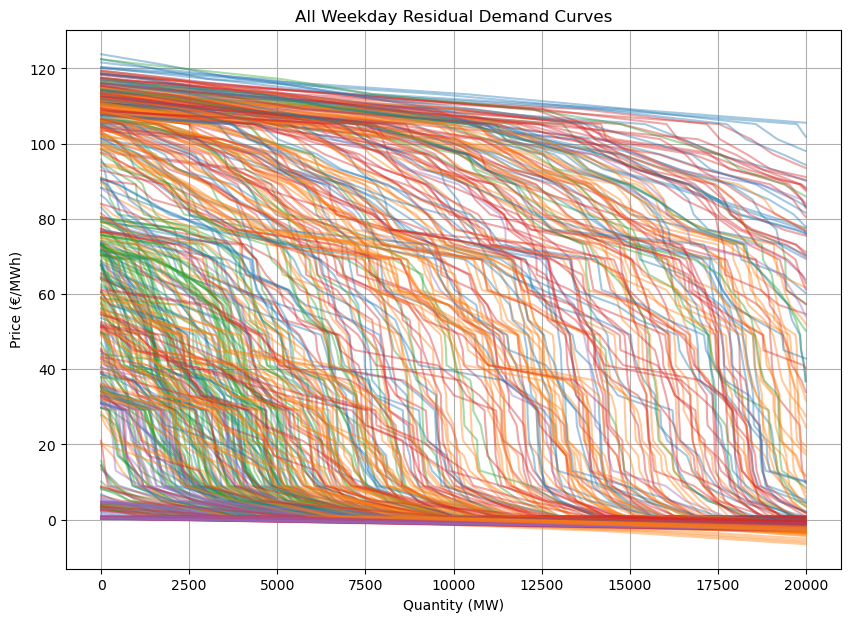

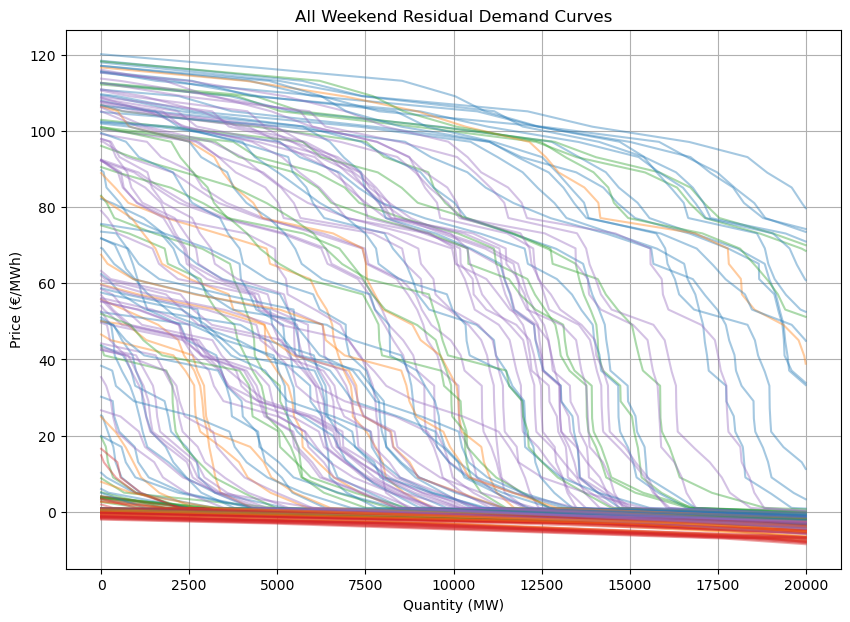

In [ ]:
colors = cm.tab10

# 평일 / 주말 분리
weekday_curves = [c for c in supply_curves if not c.get("IsWeekend", False)]
weekend_curves = [c for c in supply_curves if c.get("IsWeekend", False)]

# ========================
# (A) 평일 RDC 전체
# ========================
plt.figure(figsize=(10,7))

for curve in weekday_curves:
    cluster = curve["Cluster"]
    if cluster is None:
        continue
    
    s_agg, d_agg = curve["Supply"], curve["Demand"]
    

    # 계단 보간
    s_f = interp1d(s_agg["Price"], s_agg["Cumul"],
                   kind="previous", bounds_error=False,
                   fill_value=(0, s_agg["Cumul"].iat[-1]))
    d_f = interp1d(d_agg["Price"], d_agg["Cumul"],
                   kind="previous", bounds_error=False,
                   fill_value=(d_agg["Cumul"].iat[0], 0))

    pg = np.linspace(s_agg["Price"].min(), d_agg["Price"].max(), 500)
    sv, dv = s_f(pg), d_f(pg)

    # RDC 계산
    wf_offer_grid = np.arange(0, 20000, 10)
    rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
    if not rdc_pts:
        continue

    qv, pv = zip(*rdc_pts)
    plt.plot(qv, pv, "-", color=colors(cluster % 10), alpha=0.4)

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("All Weekday Residual Demand Curves")
plt.grid(True)
plt.show()


# ========================
# (B) 주말 RDC 전체
# ========================
plt.figure(figsize=(10,7))

for curve in weekend_curves:
    cluster = curve["Cluster"]
    if cluster is None:
        continue
    
    s_agg, d_agg = curve["Supply"], curve["Demand"]

    s_f = interp1d(s_agg["Price"], s_agg["Cumul"],
                   kind="previous", bounds_error=False,
                   fill_value=(0, s_agg["Cumul"].iat[-1]))
    d_f = interp1d(d_agg["Price"], d_agg["Cumul"],
                   kind="previous", bounds_error=False,
                   fill_value=(d_agg["Cumul"].iat[0], 0))

    pg = np.linspace(s_agg["Price"].min(), d_agg["Price"].max(), 500)
    sv, dv = s_f(pg), d_f(pg)

    wf_offer_grid = np.arange(0, 20000, 10)
    rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
    if not rdc_pts:
        continue

    qv, pv = zip(*rdc_pts)
    plt.plot(qv, pv, "-", color=colors(cluster % 10), alpha=0.4)

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("All Weekend Residual Demand Curves")
plt.grid(True)
plt.show()


# 클러스터링 별 분포 추정

In [80]:
# def plot_kde_by_cluster(curves, title_prefix=""):
#     clusters = sorted(set(c["Cluster"] for c in curves if c["Cluster"] is not None))
    
#     for cl in clusters:
#         cluster_curves = [c for c in curves if c["Cluster"] == cl]
        
#         all_sup_q, all_sup_p = [], []
#         all_dem_q, all_dem_p = [], []
        
#         for curve in cluster_curves:
#             # 공급곡선
#             s_agg = curve["Supply"]
#             all_sup_q.extend(s_agg["Cumul"].values)
#             all_sup_p.extend(s_agg["Price"].values)
            
#             # 수요곡선
#             d_agg = curve["Demand"]
#             all_dem_q.extend(d_agg["Cumul"].values)
#             all_dem_p.extend(d_agg["Price"].values)
        
#         # ==========================
#         # (A) 공급곡선 KDE
#         # ==========================
#         plt.figure(figsize=(8,6))
#         sns.kdeplot(
#             x=all_sup_q, y=all_sup_p, fill=True, cmap="Blues",
#             thresh=0.05, levels=20, alpha=0.6
#         )
#         plt.scatter(all_sup_q, all_sup_p, s=5, alpha=0.2, color="blue")
#         plt.xlabel("Quantity (MW)")
#         plt.ylabel("Price (€/MWh)")
#         plt.title(f"{title_prefix} Cluster {cl}: Supply Curve KDE")
#         plt.grid(True)
#         plt.show()
        
#         # ==========================
#         # (B) 수요곡선 KDE
#         # ==========================
#         plt.figure(figsize=(8,6))
#         sns.kdeplot(
#             x=all_dem_q, y=all_dem_p, fill=True, cmap="Reds",
#             thresh=0.05, levels=20, alpha=0.6
#         )
#         plt.scatter(all_dem_q, all_dem_p, s=5, alpha=0.2, color="red")
#         plt.xlabel("Quantity (MW)")
#         plt.ylabel("Price (€/MWh)")
#         plt.title(f"{title_prefix} Cluster {cl}: Demand Curve KDE")
#         plt.grid(True)
#         plt.show()


# # ========================
# # 주말 / 평일 구분
# # ========================
# weekend_curves = [c for c in supply_curves if c.get("IsWeekend", False)]
# weekday_curves = [c for c in supply_curves if not c.get("IsWeekend", False)]

# # 주말 클러스터별 KDE
# plot_kde_by_cluster(weekend_curves, title_prefix="Weekend")

# # 평일 클러스터별 KDE
# plot_kde_by_cluster(weekday_curves, title_prefix="Weekday")


In [ ]:
# 끝에 잘 추정해보려고
def kde_modal_supply(cluster_curves, q_grid, bw=0.2):
    # bw가 크면 매끈해지지만 디테일을 잡지못하고, 작으면 과적합
    # 공급: P_s(Q)
    all_q, all_p = [], []
    for c in cluster_curves:
        s = c["Supply"]
        all_q.extend(s["Cumul"].values)
        all_p.extend(s["Price"].values)
    if not all_q: return None
    vals = np.vstack([all_q, all_p])
    kde  = gaussian_kde(vals, bw_method=bw)

    pmin, pmax = np.nanmin(all_p), np.nanmax(all_p)
    p_axis = np.linspace(pmin, pmax, 400)
    modal_p = []
    for q in q_grid: # 대표곡선뽑으려고
        pts = np.vstack([np.full_like(p_axis, q), p_axis])
        dens = kde(pts)
        modal_p.append(p_axis[np.argmax(dens)])
        # cdf = np.cumsum(dens) / np.sum(dens)
        # modal_p.append(np.interp(0.5, cdf, p_axis)) # 3번: weighted 중앙값
    return np.array(modal_p)

def kde_modal_demand(cluster_curves, q_grid, bw=0.2):
    # 수요: P_d(Q)
    all_q, all_p = [], []
    for c in cluster_curves:
        d = c["Demand"]
        all_q.extend(d["Cumul"].values)
        all_p.extend(d["Price"].values)
    if not all_q: return None
    vals = np.vstack([all_q, all_p])
    kde  = gaussian_kde(vals, bw_method=bw)

    pmin, pmax = np.nanmin(all_p), np.nanmax(all_p)
    p_axis = np.linspace(pmin, pmax, 400)
    modal_p = []
    for q in q_grid:
        pts = np.vstack([np.full_like(p_axis, q), p_axis])
        dens = kde(pts)
        modal_p.append(p_axis[np.argmax(dens)]) # 1번: 최빈값
        # modal_p.append(np.average(p_axis, weights=dens)) # 2번: 평균값
        # cdf = np.cumsum(dens) / np.sum(dens)
        # modal_p.append(np.interp(0.5, cdf, p_axis)) # 3번: weighted 중앙값

    return np.array(modal_p)
def rdc_from_modal_curves(q_grid, sup_p_of_q, dem_p_of_q, wf_offer_grid,
                          fill='extrapolate'):
    """
    modal 공급/수요(P(Q)) → Q(P)로 뒤집은 뒤,
    각 q_wf에 대해 D(P)-S(P)-q_wf = 0의 해 P를 찾는다.
    """
    invS = invert_P_of_Q_to_Q_of_P(q_grid, sup_p_of_q, fill=fill)
    invD = invert_P_of_Q_to_Q_of_P(q_grid, dem_p_of_q, fill=fill)
    if invS is None or invD is None:
        return []

    S_Q_of_P, Ps_min_S, Ps_max_S = invS
    D_Q_of_P, Ps_min_D, Ps_max_D = invD

    # 해 탐색 가능한 공통 가격 구간
    Pmin = max(Ps_min_S, Ps_min_D)
    Pmax = min(Ps_max_S, Ps_max_D)
    if not np.isfinite(Pmin) or not np.isfinite(Pmax) or Pmax <= Pmin:
        return []

    # 브래킷에서 부호변화 확인용 샘플 그리드
    Pgrid = np.linspace(Pmin, Pmax, 600)

    rdc_pts = []
    for q_wf in wf_offer_grid:
        # 잔차 함수: R(P) = D(P) - S(P) - q_wf
        R = D_Q_of_P(Pgrid) - S_Q_of_P(Pgrid) - q_wf
        sign = np.sign(R)
        flips = np.where(np.diff(np.sign(R)) != 0)[0]
        if len(flips) == 0:
            continue
        # 첫 번째 교차만 채택(원하면 모든 교차 반복)
        i = flips[0]
        a, b = Pgrid[i], Pgrid[i+1]
        def resid(P):
            return float(D_Q_of_P(P) - S_Q_of_P(P) - q_wf)
        try:
            sol = root_scalar(resid, bracket=[a, b], method='bisect')
            if sol.converged:
                rdc_pts.append((q_wf, sol.root))
        except Exception:
            pass

    return rdc_pts

def invert_P_of_Q_to_Q_of_P(q_grid, p_of_q, *, fill='extrapolate'):
    """
    modal처럼 얻은 P(Q)를 Q(P)로 뒤집는다.
    - P가 단조가 아닐 수 있어, P 기준으로 정렬하고 같은 P가 여러개면
      그 P에서의 '대표 Q'를 선택(여기선 평균)한다.
    """
    q = np.asarray(q_grid).astype(float)
    p = np.asarray(p_of_q).astype(float)

    # 유효값만
    m = np.isfinite(q) & np.isfinite(p)
    q, p = q[m], p[m]
    if len(q) < 4:
        return None  # 뒤집을 정보 부족

    # P 기준 정렬
    order = np.argsort(p)
    p_sorted = p[order]
    q_sorted = q[order]

    # 같은 P가 여러 개면 평균 Q 사용(원하면 최대/최소로 바꿔도 됨)
    # (정밀하게 하려면 binning 후 평균)a
    uniq_p, idxs = np.unique(p_sorted, return_inverse=True)
    q_acc = np.zeros_like(uniq_p, dtype=float)
    cnt   = np.zeros_like(uniq_p, dtype=float)
    for i, k in enumerate(idxs):
        q_acc[k] += q_sorted[i]
        cnt[k]   += 1.0
    q_rep = q_acc / np.maximum(cnt, 1.0)

    # 이제 Q(P) 보간 함수
    Q_of_P = interp1d(uniq_p, q_rep,
                      kind='linear', bounds_error=False, fill_value=fill)
    return Q_of_P, float(np.nanmin(uniq_p)), float(np.nanmax(uniq_p))

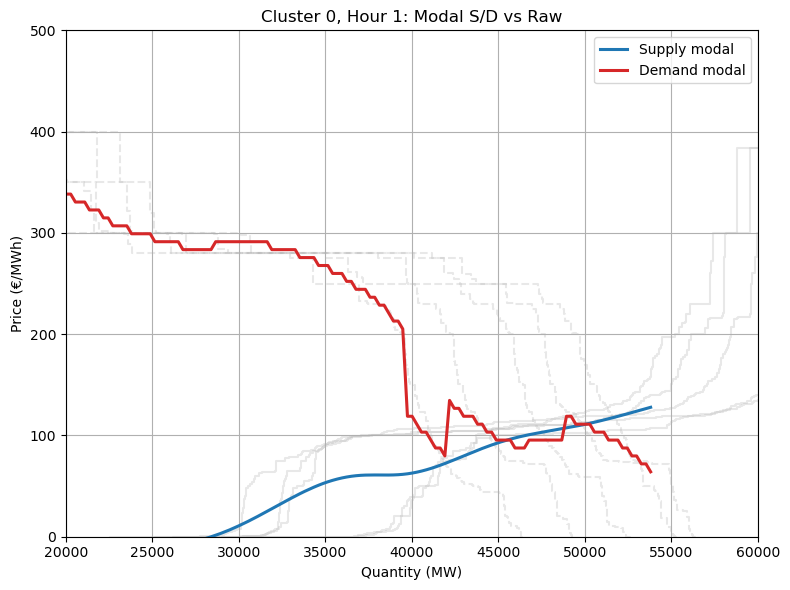

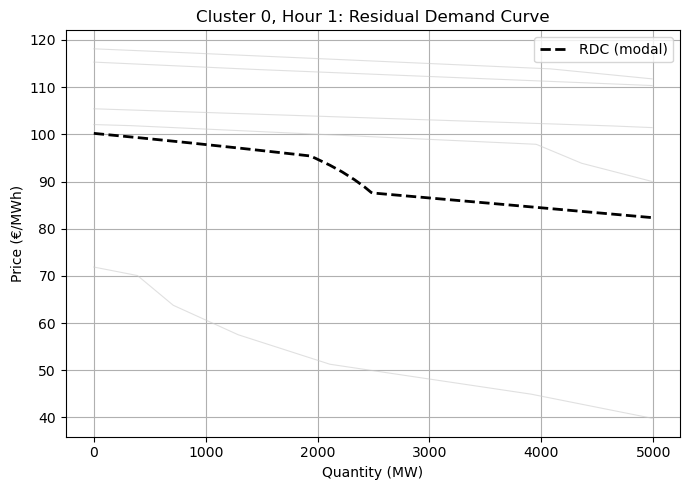

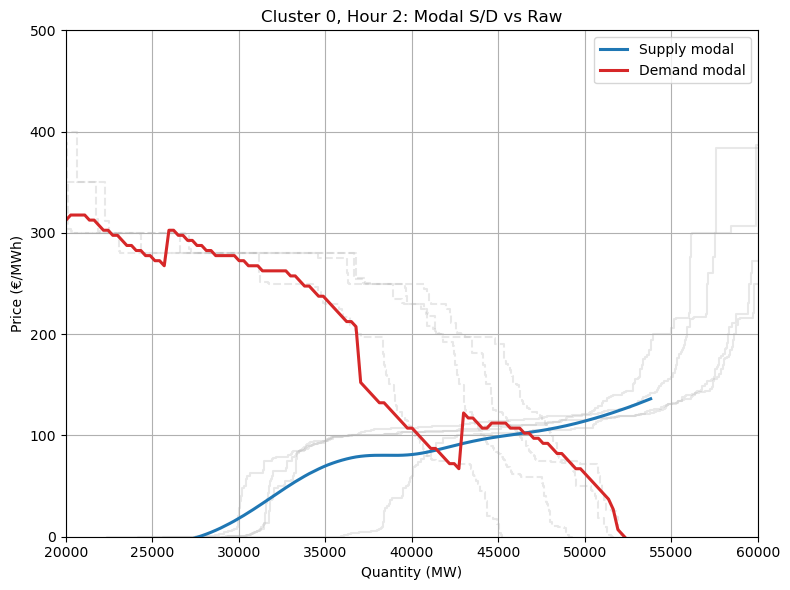

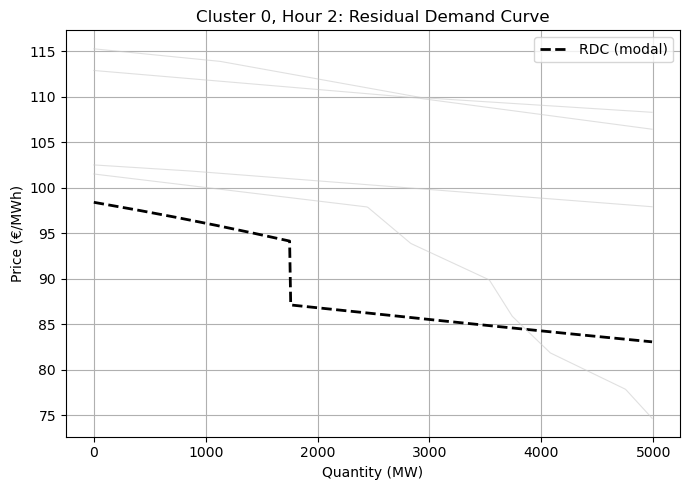

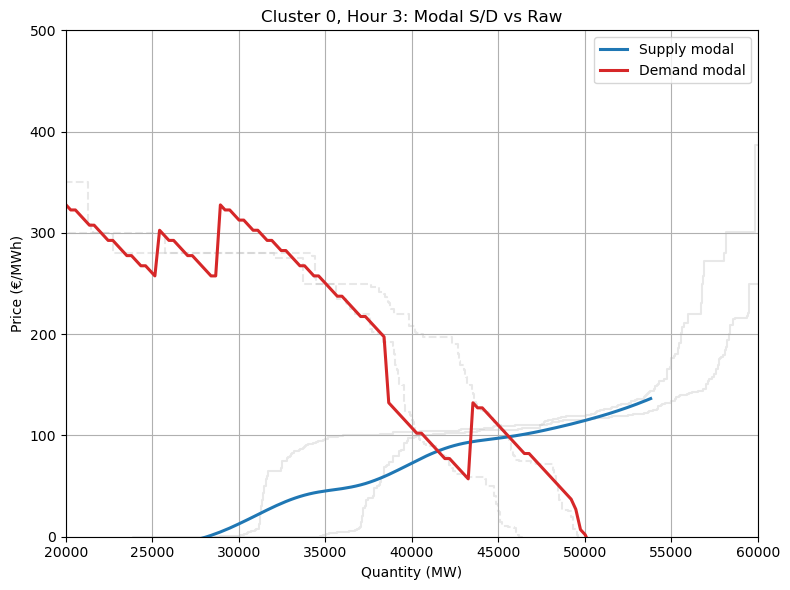

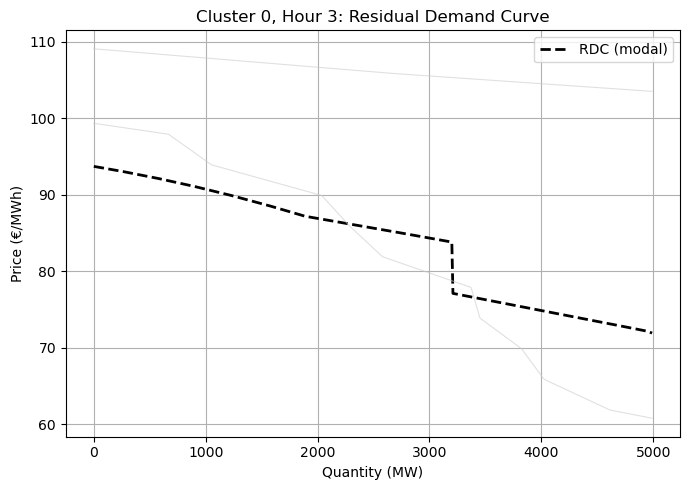

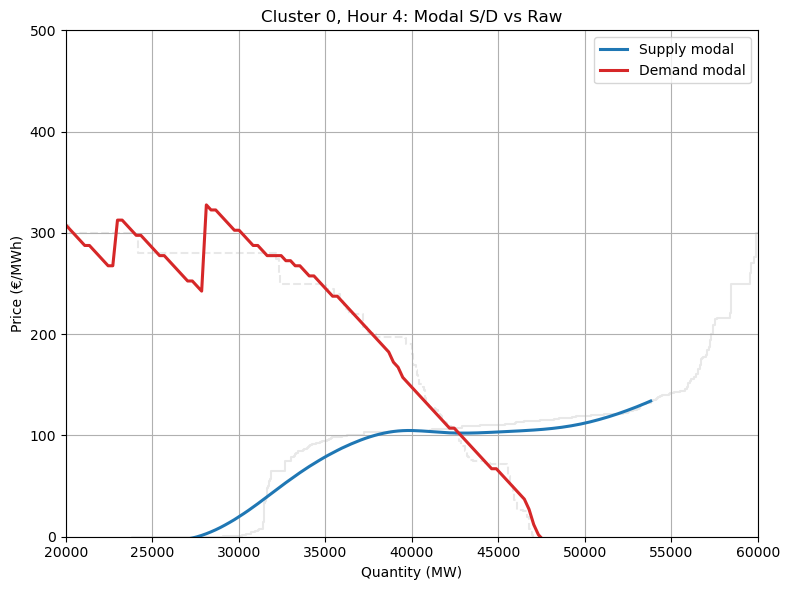

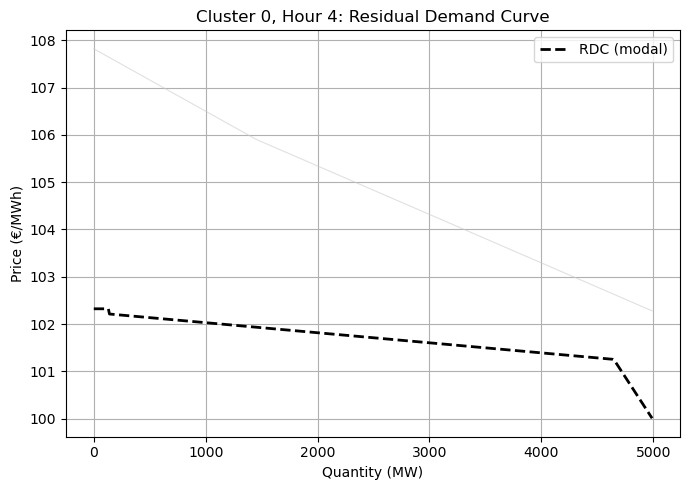

KeyboardInterrupt: 

In [87]:
# ---- run per (cluster, hour) ----
q_max = max(max(curve["Demand"]["Cumul"]) for curve in cluster_curves)
q_grid = np.linspace(0, q_max, 200)
# q_grid = np.linspace(0, 80000, 300)
wf_offer_grid = np.arange(0, 5000, 10)

clusters = sorted(set(c["Cluster"] for c in supply_curves if c["Cluster"] is not None))
for c in clusters:
    for h in range(1, 25):
        members = [cur for cur in supply_curves
                   if cur["Cluster"] == c and int(cur["Datetime"].split()[-1]) == h]
        if not members:
            continue

        sup_modal = kde_modal_supply(members, q_grid, bw=0.2)
        dem_modal = kde_modal_demand(members, q_grid, bw=0.2)
        if sup_modal is None or dem_modal is None:
            continue

        # (A) 원본 곡선(회색) + modal 곡선(파/빨)
        plt.figure(figsize=(8,6))
        for cur in members:
            plt.step(cur["Supply"]["Cumul"],  cur["Supply"]["Price"],
                     where="post", color="0.7", alpha=0.3)
            plt.step(cur["Demand"]["Cumul"],  cur["Demand"]["Price"],
                     where="post", color="0.7", alpha=0.3, linestyle="--")
        plt.plot(q_grid, sup_modal, color="tab:blue", lw=2.2, label="Supply modal")
        plt.plot(q_grid, dem_modal, color="tab:red",  lw=2.2, label="Demand modal")
        plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
        plt.ylim(0, 500)
        plt.xlim(20000, 60000)

        plt.title(f"Cluster {c}, Hour {h}: Modal S/D vs Raw")
        plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

        # (B) modal 곡선으로 RDC 계산 (이제는 Q(P)로 뒤집어 계산!)
        rdc = rdc_from_modal_curves(q_grid, sup_modal, dem_modal, wf_offer_grid)
        plt.figure(figsize=(7,5))
        if rdc:
            qv, pv = zip(*rdc)
            plt.plot(qv, pv, "k--", lw=2, label="RDC (modal)")
        for cur in members:  
            s, d = cur["Supply"], cur["Demand"]
            fS = interp1d(s["Price"], s["Cumul"], kind="previous",
                        bounds_error=False, fill_value=(0, s["Cumul"].iat[-1]))
            fD = interp1d(d["Price"], d["Cumul"], kind="previous",
                        bounds_error=False, fill_value=(d["Cumul"].iat[0], 0))
            P = np.linspace(max(s["Price"].min(), d["Price"].min()),
                            min(s["Price"].max(), d["Price"].max()), 500)
            sv, dv = fS(P), fD(P)

            rdc_pts_scn = compute_rdc_by_sign_change(P, dv, sv, wf_offer_grid)
            if rdc_pts_scn:
                q_scn, p_scn = zip(*rdc_pts_scn)
                plt.plot(q_scn, p_scn, color="0.8", lw=0.8, alpha=0.6)
        # # 참고용: 몇 개의 실제 RDC도 회색으로
        # for cur in members[:6]:  # 과밀 방지용 샘플
        #     s, d = cur["Supply"], cur["Demand"]
        #     fS = interp1d(s["Price"], s["Cumul"], kind="previous",
        #                   bounds_error=False, fill_value=(0, s["Cumul"].iat[-1]))
        #     fD = interp1d(d["Price"], d["Cumul"], kind="previous",
        #                   bounds_error=False, fill_value=(d["Cumul"].iat[0], 0))
        #     P = np.linspace(max(s["Price"].min(), d["Price"].min()),
        #                     min(s["Price"].max(), d["Price"].max()), 500)
        #     sv, dv = fS(P), fD(P)
        #     r0 = []
        #     for q in wf_offer_grid[::10]:
        #         R = dv - sv - q
        #         sign = np.sign(R); flip = np.where(np.diff(sign)!=0)[0]
        #         if len(flip): r0.append((q, P[flip[0]]))
        #     if r0:
        #         q0, p0 = zip(*r0)
        #         plt.plot(q0, p0, color="0.8", lw=0.8, alpha=0.6)
        plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
        plt.title(f"Cluster {c}, Hour {h}: Residual Demand Curve")
        plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


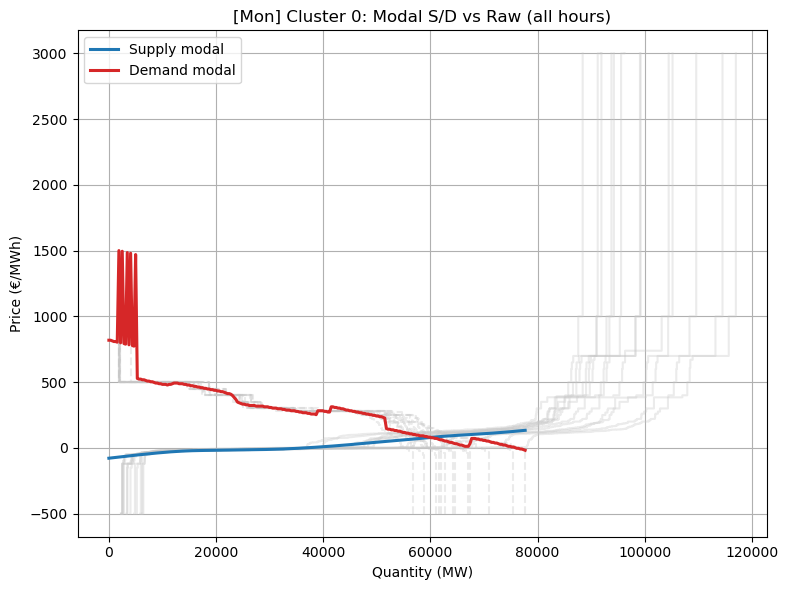

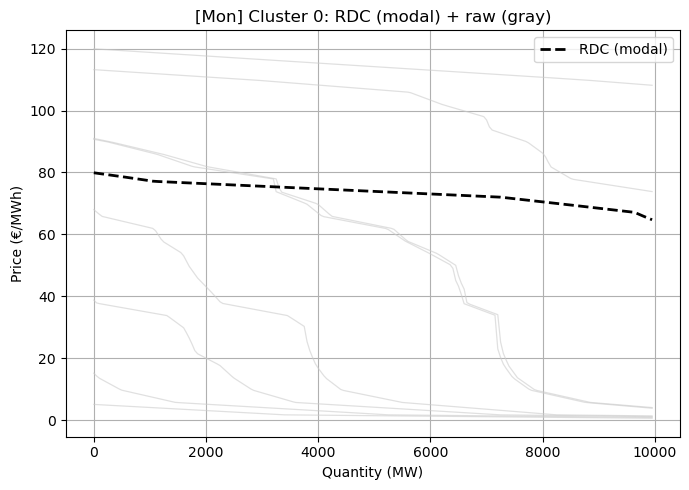

KeyboardInterrupt: 

In [88]:
# ---------------------------------------
# 0) 준비: supply_curves에 Weekday 필드 없으면 추가
# ---------------------------------------
for c in supply_curves:
    if "Weekday" not in c:
        # Datetime: "YYYYMMDD H" 형식 가정
        date_str = c["Datetime"].split()[0]
        d = pd.to_datetime(date_str, format="%Y%m%d")
        c["Weekday"] = d.weekday()  # 0=Mon ... 6=Sun

# 요일명 매핑
weekday_name = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}

# ---------------------------------------
# 1) 설정값
# ---------------------------------------
wf_offer_grid = np.arange(0, 10000, 50)  # 필요에 맞게
bw_supply = 0.2
bw_demand = 0.2

# ---------------------------------------
# 2) 요일별, 클러스터별로(시간 무시) 멤버 모아서 단 한 번 KDE 추정
# ---------------------------------------
clusters_all = sorted(set(c["Cluster"] for c in supply_curves if c["Cluster"] is not None))
weekdays_all = sorted(set(c["Weekday"] for c in supply_curves))

for wd in weekdays_all:
    for cl in clusters_all:
        # (a) 이 요일 & 이 클러스터의 모든 시간 데이터를 멤버로 수집
        members = [cur for cur in supply_curves
                   if cur["Weekday"] == wd and cur["Cluster"] == cl]
        if not members:
            continue

        # (b) q_grid 범위(해당 멤버들의 수요 누적 최대치 기준으로 안전하게)
        try:
            q_max = max(float(cur["Demand"]["Cumul"].max()) for cur in members if not cur["Demand"].empty)
        except ValueError:
            continue
        if not np.isfinite(q_max) or q_max <= 0:
            continue
        q_grid = np.linspace(0, q_max, 250)

        # (c) KDE modal/quantile 추정 (여기서는 modal만. 원하면 quantile도 추가 가능)
        sup_modal = kde_modal_supply(members, q_grid, bw=bw_supply)
        dem_modal = kde_modal_demand(members, q_grid, bw=bw_demand)
        if sup_modal is None or dem_modal is None:
            continue

        # ---------------------------------------
        # (A) 원본(회색) + 요일·클러스터 단일 modal 곡선(파/빨) 시각화
        # ---------------------------------------
        plt.figure(figsize=(8,6))
        # 원본 곡선(회색)
        for cur in members:
            # 공급
            s = cur["Supply"]
            if not s.empty:
                plt.step(s["Cumul"], s["Price"], where="post", color="0.78", alpha=0.35)
            # 수요
            d = cur["Demand"]
            if not d.empty:
                plt.step(d["Cumul"], d["Price"], where="post", color="0.78", alpha=0.35, linestyle="--")

        # 대표 modal 곡선
        plt.plot(q_grid, sup_modal, color="tab:blue", lw=2.2, label="Supply modal")
        plt.plot(q_grid, dem_modal, color="tab:red",  lw=2.2, label="Demand modal")

        plt.xlabel("Quantity (MW)")
        plt.ylabel("Price (€/MWh)")
        plt.title(f"[{weekday_name[wd]}] Cluster {cl}: Modal S/D vs Raw (all hours)")
        plt.grid(True); plt.legend(); plt.tight_layout()
        plt.show()

        # ---------------------------------------
        # (B) RDC: modal S/D로 계산 + 참고용 raw RDC 일부 회색
        # ---------------------------------------
        plt.figure(figsize=(7,5))

        # 참고용 raw RDC (과밀 방지: 최대 8개만)
        sample_raw = members[:8]
        for cur in sample_raw:
            s, d = cur["Supply"], cur["Demand"]
            if s.empty or d.empty:
                continue
            fS = interp1d(s["Price"], s["Cumul"], kind="previous",
                          bounds_error=False, fill_value=(0, s["Cumul"].iat[-1]))
            fD = interp1d(d["Price"], d["Cumul"], kind="previous",
                          bounds_error=False, fill_value=(d["Cumul"].iat[0], 0))
            Pmin = max(s["Price"].min(), d["Price"].min())
            Pmax = min(s["Price"].max(), d["Price"].max())
            if not np.isfinite(Pmin) or not np.isfinite(Pmax) or Pmax <= Pmin:
                continue
            P = np.linspace(Pmin, Pmax, 500)
            sv, dv = fS(P), fD(P)
            rdc_raw = compute_rdc_by_sign_change(P, dv, sv, wf_offer_grid)
            if rdc_raw:
                q_raw, p_raw = zip(*rdc_raw)
                plt.plot(q_raw, p_raw, color="0.8", lw=0.9, alpha=0.6)

        # modal 곡선 기반 RDC
        rdc_modal = rdc_from_modal_curves(q_grid, sup_modal, dem_modal, wf_offer_grid)
        if rdc_modal:
            qv, pv = zip(*rdc_modal)
            plt.plot(qv, pv, "k--", lw=2, label="RDC (modal)")

        plt.xlabel("Quantity (MW)")
        plt.ylabel("Price (€/MWh)")
        plt.title(f"[{weekday_name[wd]}] Cluster {cl}: RDC (modal) + raw (gray)")
        plt.grid(True); plt.legend(); plt.tight_layout()
        plt.show()


샘플링시ㄷ도

In [95]:
def kde_quantile_supply_curves(cluster_curves, q_grid, bw=0.2, quantiles=[0.1,0.3,0.5,0.7,0.9]):
    """공급: 여러 분위수 기반 곡선 반환"""
    all_q, all_p = [], []
    for c in cluster_curves:
        s = c["Supply"]
        all_q.extend(s["Cumul"].values)
        all_p.extend(s["Price"].values)
    if not all_q:
        return {}

    vals = np.vstack([all_q, all_p])
    kde  = gaussian_kde(vals, bw_method=bw)

    pmin, pmax = np.nanmin(all_p), np.nanmax(all_p)
    p_axis = np.linspace(pmin, pmax, 400)

    curves = {}
    for qtile in quantiles:
        curve = []
        for q in q_grid:
            pts = np.vstack([np.full_like(p_axis, q), p_axis])
            dens = kde(pts)
            cdf = np.cumsum(dens) / np.sum(dens)
            curve.append(np.interp(qtile, cdf, p_axis))
        curves[qtile] = np.array(curve)
    return curves
# 수요 quantile curves (joint KDE에서 Q→P 분위수)
def kde_quantile_demand_curves(cluster_curves, q_grid, bw=0.2, quantiles=[0.1,0.5,0.9]):
    all_q, all_p = [], []
    for c in cluster_curves:
        d = c["Demand"]
        all_q.extend(d["Cumul"].values)
        all_p.extend(d["Price"].values)
    if not all_q:
        return None
    
    vals = np.vstack([all_q, all_p])
    kde  = gaussian_kde(vals, bw_method=bw)

    pmin, pmax = np.nanmin(all_p), np.nanmax(all_p)
    p_axis = np.linspace(pmin, pmax, 400)

    curves = {}
    for q in q_grid:
        pts = np.vstack([np.full_like(p_axis, q), p_axis])
        dens = kde(pts)
        cdf = np.cumsum(dens) / np.sum(dens)
        for qtile in quantiles:
            p_q = np.interp(qtile, cdf, p_axis)
            curves.setdefault(qtile, []).append(p_q)
    
    return {qtile: np.array(p_list) for qtile, p_list in curves.items()}

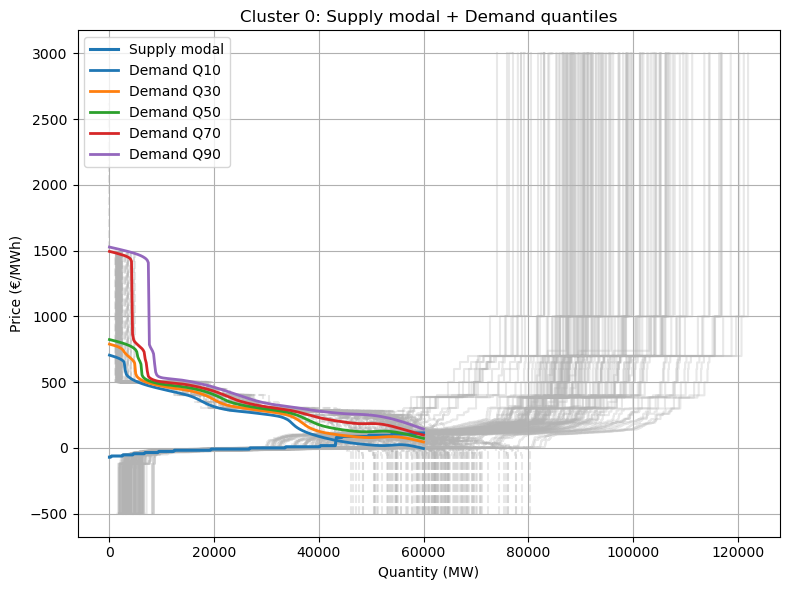

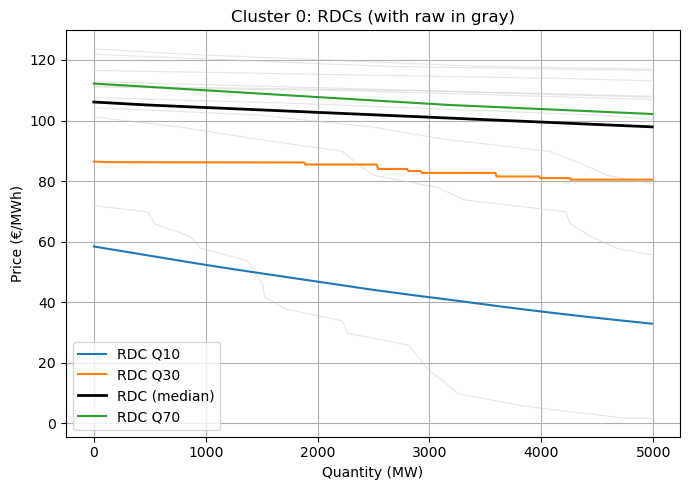

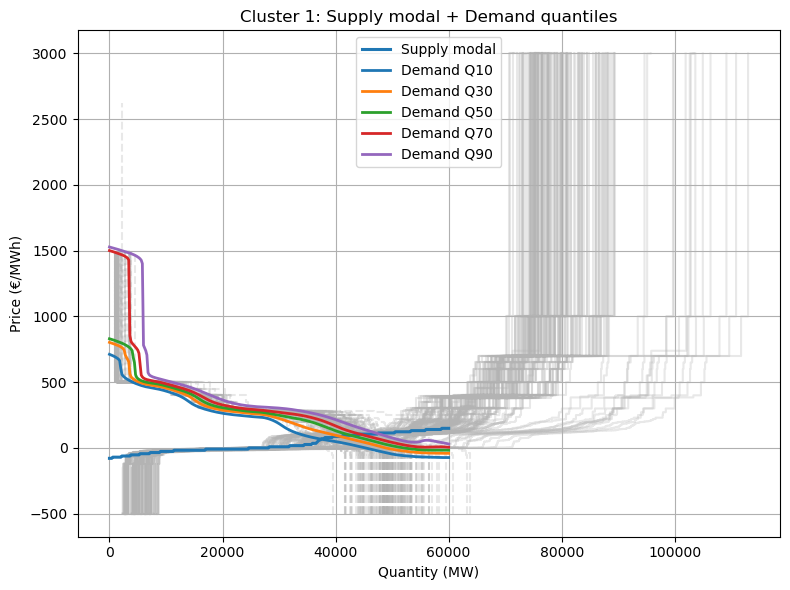

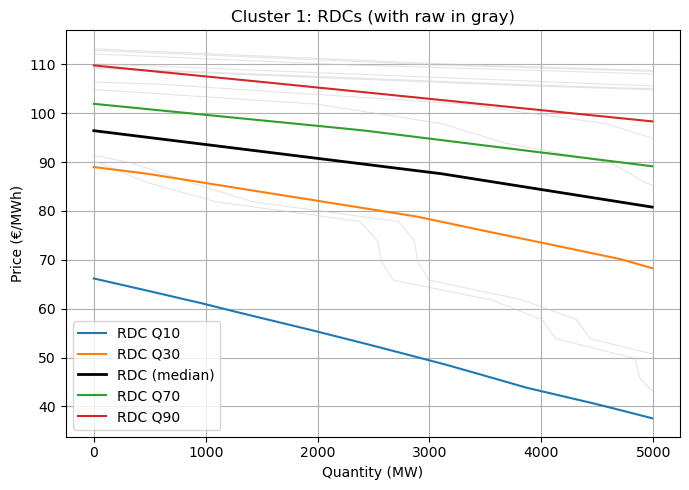

KeyboardInterrupt: 

In [97]:
q_grid = np.linspace(0, 60000, 300)   # Q 축
wf_offer_grid = np.arange(0, 5000, 10)

clusters = sorted(set(c["Cluster"] for c in supply_curves if c["Cluster"] is not None))

for c in clusters:
    members = [cur for cur in supply_curves if cur["Cluster"] == c]
    if not members:
        continue

    # 공급 modal curve
    sup_modal = kde_modal_supply(members, q_grid, bw=0.2)

    # 수요 분위수 curves
    dem_curves = kde_quantile_demand_curves(
        members, q_grid, bw=0.2, quantiles=[0.1,0.3,0.5,0.7,0.9]
    )
    if sup_modal is None or not dem_curves:
        continue

    # (A) 공급/수요 곡선 시각화
    plt.figure(figsize=(8,6))
    for cur in members:
        plt.step(cur["Supply"]["Cumul"], cur["Supply"]["Price"],
                 where="post", color="0.7", alpha=0.3)
        plt.step(cur["Demand"]["Cumul"], cur["Demand"]["Price"],
                 where="post", color="0.7", alpha=0.3, linestyle="--")

    plt.plot(q_grid, sup_modal, color="tab:blue", lw=2.2, label="Supply modal")
    for qtile, dem_curve in dem_curves.items():
        plt.plot(q_grid, dem_curve, lw=2, label=f"Demand Q{int(qtile*100)}")

    plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
    plt.title(f"Cluster {c}: Supply modal + Demand quantiles")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # (B) RDC 계산
    plt.figure(figsize=(7,5))
    # --- 개별 멤버의 RDC 회색 ---
    for cur in members[:10]:
        s, d = cur["Supply"], cur["Demand"]
        fS = interp1d(s["Price"], s["Cumul"], kind="previous",
                      bounds_error=False, fill_value=(0, s["Cumul"].iat[-1]))
        fD = interp1d(d["Price"], d["Cumul"], kind="previous",
                      bounds_error=False, fill_value=(d["Cumul"].iat[0], 0))
        P = np.linspace(max(s["Price"].min(), d["Price"].min()),
                        min(s["Price"].max(), d["Price"].max()), 500)
        sv, dv = fS(P), fD(P)
        rdc_pts_scn = compute_rdc_by_sign_change(P, dv, sv, wf_offer_grid)
        if rdc_pts_scn:
            q_scn, p_scn = zip(*rdc_pts_scn)
            plt.plot(q_scn, p_scn, color="0.8", lw=0.8, alpha=0.5)

    # --- 대표(modal) + 분위수 기반 RDC ---
    for qtile, dem_curve in dem_curves.items():
        rdc = rdc_from_modal_curves(q_grid, sup_modal, dem_curve, wf_offer_grid)
        if rdc:
            qv, pv = zip(*rdc)
            if qtile == 0.5:
                plt.plot(qv, pv, "k-", lw=2, label="RDC (median)")
            else:
                plt.plot(qv, pv, lw=1.5, label=f"RDC Q{int(qtile*100)}")

    plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
    plt.title(f"Cluster {c}: RDCs (with raw in gray)")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


### Joint PDF 만들기

In [ ]:
# def collect_points_QPTF(cluster_curves, context_df):
#     """
#     cluster_curves: supply_curves 중 특정 클러스터에 속한 멤버들의 리스트
#       각 멤버: {"Datetime": "...", "Supply": s_agg, "Demand": d_agg, ...}
#     context_df: Datetime별 T(온도), value(수요예측) 보유한 DF (예: df_forecast 병합본)
#       필요 컬럼: ["Datetime", "T", "value"]
#     return:
#       dict with arrays for supply and demand:
#       {"sup": {"q":..., "p":..., "t":..., "f":...},
#        "dem": {"q":..., "p":..., "t":..., "f":...}}
#     """
#     # Datetime → (T, F) 맵
#     ctx_map = context_df.set_index("Datetime")[["T","value"]].to_dict(orient="index")

#     sup_q, sup_p, sup_t, sup_f = [], [], [], []
#     dem_q, dem_p, dem_t, dem_f = [], [], [], []

#     for cur in cluster_curves:
#         dt = cur["Datetime"]
#         ctx = ctx_map.get(dt)
#         if ctx is None:
#             continue
#         Tdt = float(ctx["T"]) if pd.notna(ctx["T"]) else np.nan
#         Fdt = float(ctx["value"]) if pd.notna(ctx["value"]) else np.nan
#         if not np.isfinite(Tdt) or not np.isfinite(Fdt):
#             continue

#         # 공급
#         s = cur["Supply"]
#         if not s.empty:
#             sup_q.extend(s["Cumul"].values)
#             sup_p.extend(s["Price"].values)
#             sup_t.extend([Tdt]*len(s))
#             sup_f.extend([Fdt]*len(s))
#         # 수요
#         d = cur["Demand"]
#         if not d.empty:
#             dem_q.extend(d["Cumul"].values)
#             dem_p.extend(d["Price"].values)
#             dem_t.extend([Tdt]*len(d))
#             dem_f.extend([Fdt]*len(d))

#     sup = {"q": np.array(sup_q), "p": np.array(sup_p),
#            "t": np.array(sup_t), "f": np.array(sup_f)}
#     dem = {"q": np.array(dem_q), "p": np.array(dem_p),
#            "t": np.array(dem_t), "f": np.array(dem_f)}
#     return {"sup": sup, "dem": dem}


In [161]:
def _gauss(u):  # 표준 가우스 커널
    return np.exp(-0.5*u*u) / np.sqrt(2*np.pi)

def _effective_n(w):
    s1 = np.sum(w); s2 = np.sum(w*w)
    return (s1*s1)/s2 if s2>0 else 0.0

def _mono_fix(y, increasing=True):
    m = np.isfinite(y)
    if m.sum() < 4:
        return y
    ir = IsotonicRegression(increasing=increasing, out_of_bounds='clip')
    y_fit = ir.fit_transform(np.arange(len(y))[m], y[m])
    z = y.copy(); z[m] = y_fit
    return z

def modal_and_quantile_curve_QP_TFW_robust(points, q_grid, T_ctx, F_ctx, W_ctx,
                                           quantiles=(0.5,), p_res=401,
                                           kind='demand',
                                           min_neff=80, inflate=1.3):
    """
    KDE 기반 조건부 P(Q) 추정 (강건/단조 보정)
    kind: 'supply' -> 단조증가, 'demand' -> 단조감소
    """
    if points is None or len(points)==0:
        return None, {}

    Q, P, T, F, W = points.T.astype(float)

    # --- 스케일 표준화 (Q,T,F만 z-score) ---
    def z(x):
        s = np.std(x)
        return (x - np.mean(x)) / (s if s>0 else 1.0)
    Qz, Tz, Fz = z(Q), z(T), z(F)
    qz_ctx, tz_ctx, fz_ctx = z(q_grid), (T_ctx - np.mean(T))/ (np.std(T) or 1.0), (F_ctx - np.mean(F))/ (np.std(F) or 1.0)

    modal, qtiles = [], {qt: [] for qt in quantiles}

    for qi, q in enumerate(q_grid):
        # 컨텍스트 가중치 (표준화 공간)
        w = _gauss((Qz - qz_ctx[qi])) * _gauss(Tz - tz_ctx) * _gauss(Fz - fz_ctx) * _gauss((W - W_ctx)/0.4)
        # 유효표본 확인 → 너무 작으면 완화(밴드확대)
        neff = _effective_n(w)
        if neff < min_neff:
            w = _gauss((Qz - qz_ctx[qi])/inflate) * _gauss((Tz - tz_ctx)/inflate) * _gauss((Fz - fz_ctx)/inflate) * _gauss((W - W_ctx)/(0.4*inflate))
            neff = _effective_n(w)

        if neff <= 5:
            modal.append(np.nan)
            for qt in quantiles: qtiles[qt].append(np.nan)
            continue

        # 가중 분위수로 가격축 제한 (꼬리 제거)
        m = w>0
        Pw, Ww = P[m], w[m]
        if len(Pw) < 5:
            modal.append(np.nan)
            for qt in quantiles: qtiles[qt].append(np.nan)
            continue
        # 가중 분위수 계산
        order = np.argsort(Pw)
        Pw_s, Ww_s = Pw[order], Ww[order]
        c = np.cumsum(Ww_s); c /= c[-1]
        p_lo = np.interp(0.01, c, Pw_s)
        p_hi = np.interp(0.99, c, Pw_s)
        p_axis = np.linspace(p_lo, p_hi, p_res)

        # 가격축 KDE (가중)
        # Silverman hp 대신 표준화-불필요, 축 자체에서 h는 자동으로 p축 범위/분해능로 흡수
        # 밀도 ∝ sum w * φ((P - p)/hp) ; 여기선 hp를 p축 분해능으로 대체
        # 수치 안정성을 위해 벡터화
        dif = (Pw_s[:,None] - p_axis[None,:])
        # hp 적당히 (가격 단위가 크면 10~20; 상대적이면 np.ptp(P)/100 등)
        hp = max(np.ptp(Pw_s)/80, 5.0)
        kde = (Ww_s[:,None] * _gauss(dif/hp)).sum(axis=0)

        # modal
        modal.append(p_axis[np.argmax(kde)])
        # 분위수
        cdf = np.cumsum(kde); 
        if cdf[-1] > 0:
            cdf /= cdf[-1]
            for qt in quantiles:
                qtiles[qt].append(np.interp(qt, cdf, p_axis))
        else:
            for qt in quantiles:
                qtiles[qt].append(np.nan)

    modal = np.array(modal)
    for qt in quantiles:
        qtiles[qt] = np.array(qtiles[qt])

    # --- 단조 보정 ---
    if kind == 'supply':
        modal = _mono_fix(modal, increasing=True)
        for qt in quantiles: qtiles[qt] = _mono_fix(qtiles[qt], increasing=True)
    else:  # demand
        modal = _mono_fix(modal, increasing=False)
        for qt in quantiles: qtiles[qt] = _mono_fix(qtiles[qt], increasing=False)

    return modal, qtiles


In [ ]:
def gaussian_kernel(x, h):
    # 표준 정규 가우스 커널 (정규화 상수 포함)
    return np.exp(-0.5*(x/h)**2)/(sqrt(2*pi)*h)

def weighted_1d_kde_density(x_grid, samples, weights, h):
    """
    x_grid: 평가할 x 좌표(여기서는 price 축)
    samples: 샘플 p_i
    weights: 각 샘플의 가중치 w_i (음수 금지)
    h: 대역폭
    return: 밀도 추정값 배열 (정규화 필요X: 최빈값/분위수에 충분)
    """
    x_grid = np.asarray(x_grid); samples = np.asarray(samples); weights = np.asarray(weights)
    if len(samples)==0 or len(weights)==0:
        return np.zeros_like(x_grid)
    # (x - p_i)/h에 대한 가우스 커널 합
    dens = np.zeros_like(x_grid, dtype=float)
    for p_i, w_i in zip(samples, weights):
        if w_i <= 0: 
            continue
        dens += w_i * gaussian_kernel(x_grid - p_i, h)
    # 스케일 통일을 위해 총중량으로 나눠줄 수도 있음 (모드/분위수 목적이면 생략해도 무방)
    if np.sum(weights)>0:
        dens = dens / np.sum(weights)
    return dens

In [ ]:
# def modal_and_quantile_curve_QP_TF(points, q_grid, T_ctx, F_ctx,
#                                    hq=1500.0, hT=2.0, hF=800.0, hp=10.0,
#                                    quantiles=(0.1,0.5,0.9), p_res=400):
#     """
#     points: dict {"q","p","t","f"} (collect_points_QPTF() 출력 중 하나)
#     q_grid: 대표곡선의 Q축
#     T_ctx, F_ctx: 조건부 맥락 (예: 금일 온도/수요예측의 참조값)
#     h*: 대역폭들 (단위 주의: Q는 MW, T는 °C, F는 MW, P는 €/MWh 가정)
#     return: modal_p (len(q_grid)), quantile_curves {qtile: array}
#     """
#     q = points["q"]; p = points["p"]; t = points["t"]; f = points["f"]
#     m = np.isfinite(q) & np.isfinite(p) & np.isfinite(t) & np.isfinite(f)
#     q, p, t, f = q[m], p[m], t[m], f[m]
#     if len(q) < 10:
#         return None, {}

#     # 가격 축
#     p_min, p_max = np.nanmin(p), np.nanmax(p)
#     if not np.isfinite(p_min) or not np.isfinite(p_max) or p_max <= p_min:
#         return None, {}
#     p_axis = np.linspace(p_min, p_max, p_res)

#     # 맥락 가중(온도/예측수요)
#     w_ctx = gaussian_kernel(t - T_ctx, hT) * gaussian_kernel(f - F_ctx, hF)

#     modal_p = []
#     qtile_map = {qt: [] for qt in quantiles}

#     for q0 in q_grid:
#         # Q-슬라이스 가중 (q ≈ q0)
#         w_q = gaussian_kernel(q - q0, hq)
#         w = w_ctx * w_q
#         if np.sum(w) <= 0:
#             modal_p.append(np.nan)
#             for qt in quantiles: qtile_map[qt].append(np.nan)
#             continue

#         # 가격축 KDE (가중 1D KDE)
#         dens = weighted_1d_kde_density(p_axis, p, w, hp)

#         # 모드
#         modal_p.append(p_axis[np.argmax(dens)])

#         # 분위수 (누적합 정규화 후 역보간)
#         cdf = np.cumsum(dens)
#         if cdf[-1] > 0:
#             cdf = cdf / cdf[-1]
#             for qt in quantiles:
#                 qtile_map[qt].append(np.interp(qt, cdf, p_axis))
#         else:
#             for qt in quantiles:
#                 qtile_map[qt].append(np.nan)

#     modal_p = np.array(modal_p)
#     for qt in quantiles:
#         qtile_map[qt] = np.array(qtile_map[qt])

#     return modal_p, qtile_map

In [108]:
# context_df = df_forecast.merge(df_weather[['Datetime','T']], on='Datetime', how='inner')
# clusters = sorted(set(c["Cluster"] for c in supply_curves if c["Cluster"] is not None))
# wf_offer_grid = np.arange(0, 8000, 50)

# # 맥락 예시: T=30°C, F_ctx= 28000 MW
# T_ctx = 30.0
# F_ctx = 28000.0

# for c in clusters:
#     members = [cur for cur in supply_curves if cur["Cluster"] == c]
#     if not members: 
#         continue

#     # (Q,P,T,F) 점셋 만들기
#     pts = collect_points_QPTF(members, context_df=context_df)

#     # q_grid 범위
#     try:
#         q_max = np.nanmax([cur["Demand"]["Cumul"].max() for cur in members if not cur["Demand"].empty])
#     except ValueError:
#         continue
#     if not np.isfinite(q_max) or q_max <= 0:
#         continue
#     q_grid = np.linspace(0, q_max, 250)

#     # 공급/수요: 맥락조건부 modal & quantiles
#     sup_modal, _              = modal_and_quantile_curve_QP_TF(pts["sup"], q_grid, T_ctx, F_ctx,
#                                                                hq=1500, hT=2.0, hF=800.0, hp=10.0,
#                                                                quantiles=(0.5,))
#     dem_modal, dem_qtiles_map = modal_and_quantile_curve_QP_TF(pts["dem"], q_grid, T_ctx, F_ctx,
#                                                                hq=1500, hT=2.0, hF=800.0, hp=10.0,
#                                                                quantiles=(0.1,0.3,0.5,0.7,0.9))
#     if sup_modal is None or dem_modal is None:
#         continue

#     # (A) 원본 회색 + 조건부 대표 곡선
#     import matplotlib.pyplot as plt
#     plt.figure(figsize=(8,6))
#     # 원본
#     for cur in members:
#         s, d = cur["Supply"], cur["Demand"]
#         if not s.empty:
#             plt.step(s["Cumul"], s["Price"], where="post", color="0.8", alpha=0.3)
#         if not d.empty:
#             plt.step(d["Cumul"], d["Price"], where="post", color="0.8", alpha=0.3, linestyle="--")
#     # 대표
#     plt.plot(q_grid, sup_modal, color="tab:blue", lw=2.2, label=f"Supply modal | T={T_ctx},F={F_ctx}")
#     for qt, curve in dem_qtiles_map.items():
#         lbl = "Demand median" if abs(qt-0.5)<1e-9 else f"Demand Q{int(qt*100)}"
#         style = "-" if abs(qt-0.5)<1e-9 else "--"
#         plt.plot(q_grid, curve, lw=2.0, label=lbl, linestyle=style)
#     plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
#     plt.title(f"Cluster {c}: Contextual curves (T={T_ctx}, F={F_ctx})")
#     plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

#     # (B) RDC (대표공급 + 수요분위수)
#     plt.figure(figsize=(7,5))
#     # 참고용 raw RDC 일부
#     for cur in members[:8]:
#         s, d = cur["Supply"], cur["Demand"]
#         fS = interp1d(s["Price"], s["Cumul"], kind="previous",
#                       bounds_error=False, fill_value=(0, s["Cumul"].iat[-1]))
#         fD = interp1d(d["Price"], d["Cumul"], kind="previous",
#                       bounds_error=False, fill_value=(d["Cumul"].iat[0], 0))
#         Pmin = max(s["Price"].min(), d["Price"].min())
#         Pmax = min(s["Price"].max(), d["Price"].max())
#         if not np.isfinite(Pmin) or not np.isfinite(Pmax) or Pmax <= Pmin:
#             continue
#         P = np.linspace(Pmin, Pmax, 500)
#         sv, dv = fS(P), fD(P)
#         rdc_raw = compute_rdc_by_sign_change(P, dv, sv, wf_offer_grid)
#         if rdc_raw:
#             q_raw, p_raw = zip(*rdc_raw)
#             plt.plot(q_raw, p_raw, color="0.85", lw=0.8, alpha=0.6)

#     for qt, dcurve in dem_qtiles_map.items():
#         rdc_pts = rdc_from_modal_curves(q_grid, sup_modal, dcurve, wf_offer_grid)
#         if rdc_pts:
#             qv, pv = zip(*rdc_pts)
#             if abs(qt-0.5)<1e-9:
#                 plt.plot(qv, pv, "k-", lw=2, label="RDC (median)")
#             else:
#                 plt.plot(qv, pv, lw=1.5, label=f"RDC Q{int(qt*100)}")

#     plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
#     plt.title(f"Cluster {c}: RDCs at context (T={T_ctx}, F={F_ctx})")
#     plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


요일 나누고 공급도 추가

In [110]:
def collect_points_QPTFW(members, context_df):
    """
    각 공급/수요곡선 멤버에서 (Q,P,T,F,W) 데이터를 수집한다.
    - Q: 누적량
    - P: 가격
    - T: 온도
    - F: 예측수요
    - W: 주말여부(0=평일, 1=주말)
    """
    sup_points, dem_points = [], []

    for cur in members:
        dt = cur["Datetime"]
        row = context_df[context_df["Datetime"] == dt]
        if row.empty:
            continue

        T = float(row["T"].values[0])
        F = float(row["value"].values[0])
        W = 1.0 if row["IsWeekend"].values[0] else 0.0

        # 공급곡선
        s = cur["Supply"]
        if not s.empty:
            for q, p in zip(s["Cumul"].values, s["Price"].values):
                sup_points.append((q, p, T, F, W))

        # 수요곡선
        d = cur["Demand"]
        if not d.empty:
            for q, p in zip(d["Cumul"].values, d["Price"].values):
                dem_points.append((q, p, T, F, W))

    return {
        "sup": np.array(sup_points),
        "dem": np.array(dem_points),
    }

def gaussian_kernel(x, h):
    """표준 정규 가우스 커널"""
    return np.exp(-0.5 * (x/h)**2) / (np.sqrt(2*np.pi) * h)

def modal_and_quantile_curve_QP_TFW(points, q_grid, T_ctx, F_ctx, W_ctx,
                                    hq=1500, hT=2.0, hF=800.0, hW=0.5, hp=10.0,
                                    quantiles=(0.5,), p_res=400):
    """
    KDE 기반 modal + quantile 곡선 추정 (공급/수요)
    입력:
      points: (Q,P,T,F,W) 배열
      q_grid: Quantity grid (ex. np.linspace)
      T_ctx, F_ctx, W_ctx: 조건부 맥락 변수 (온도, 수요, 주말/평일)
      hq,hT,hF,hW,hp: bandwidth
      quantiles: 분위수 리스트
    출력:
      modal_p, qtile_map
        - modal_p: modal curve (P(Q))
        - qtile_map: 분위수 곡선 dict {qt: curve}
    """
    if points is None or len(points) == 0:
        return None, {}

    Q, P, T, F, W = points.T
    modal_p = []
    qtile_map = {qt: [] for qt in quantiles}

    p_min, p_max = np.nanmin(P), np.nanmax(P)
    p_axis = np.linspace(p_min, p_max, p_res)

    for q in q_grid:
        # 컨텍스트 가중치 (온도, 수요, 주말여부)
        w_ctx = (
            gaussian_kernel(q - Q, hq) *
            gaussian_kernel(T - T_ctx, hT) *
            gaussian_kernel(F - F_ctx, hF) *
            gaussian_kernel(W - W_ctx, hW)
        )

        if np.all(w_ctx == 0):
            modal_p.append(np.nan)
            for qt in quantiles:
                qtile_map[qt].append(np.nan)
            continue

        # 가격축 KDE
        kde_vals = []
        for p0 in p_axis:
            kern = gaussian_kernel(P - p0, hp)
            kde_vals.append(np.sum(w_ctx * kern))
        kde_vals = np.array(kde_vals)

        # Modal (최빈값)
        modal_p.append(p_axis[np.argmax(kde_vals)])

        # 분위수
        cdf = np.cumsum(kde_vals)
        cdf = cdf / cdf[-1]
        for qt in quantiles:
            qtile_map[qt].append(np.interp(qt, cdf, p_axis))

    # 배열 변환
    modal_p = np.array(modal_p)
    for qt in quantiles:
        qtile_map[qt] = np.array(qtile_map[qt])

    return modal_p, qtile_map


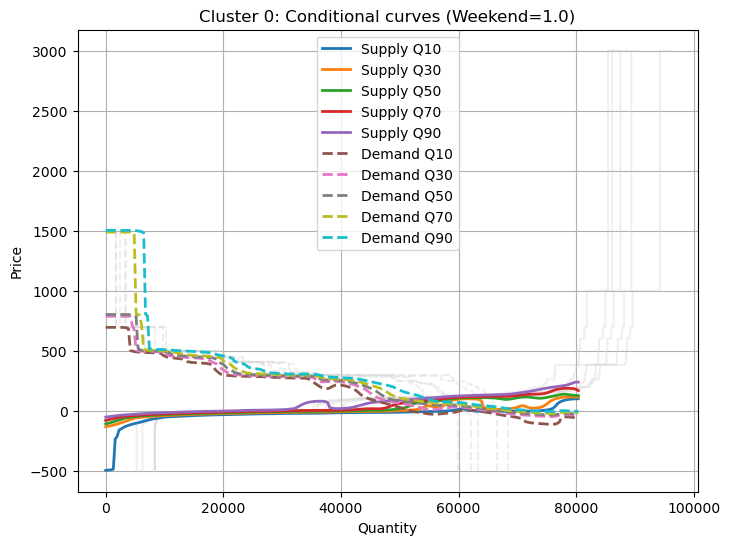

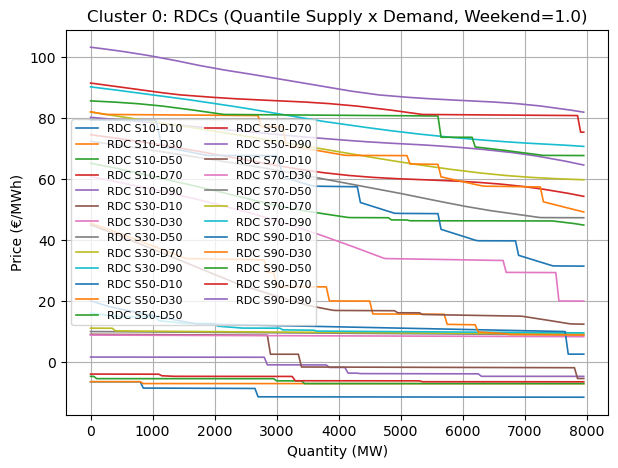

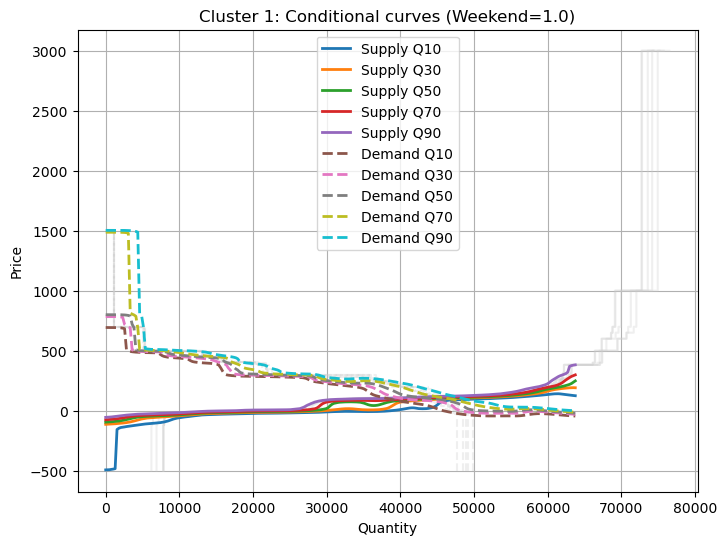

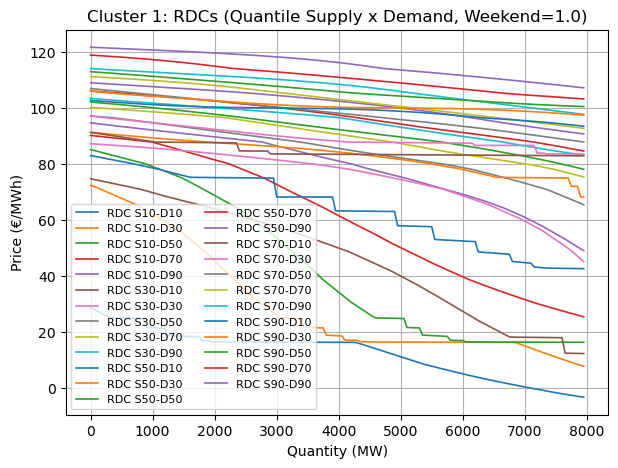

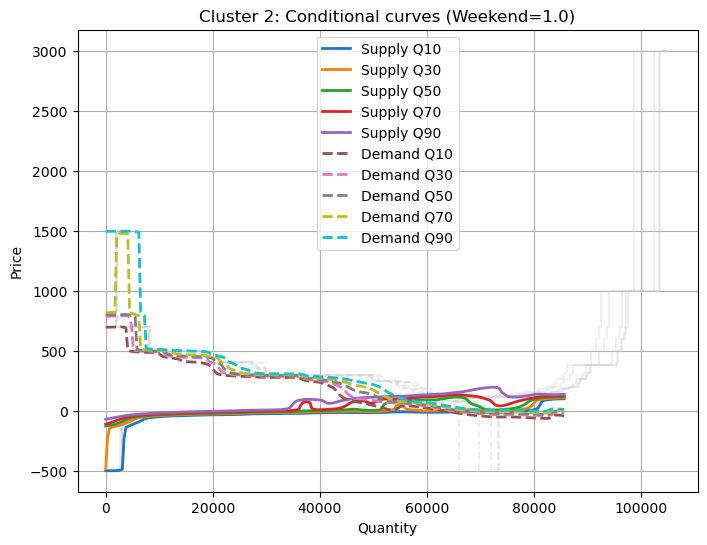

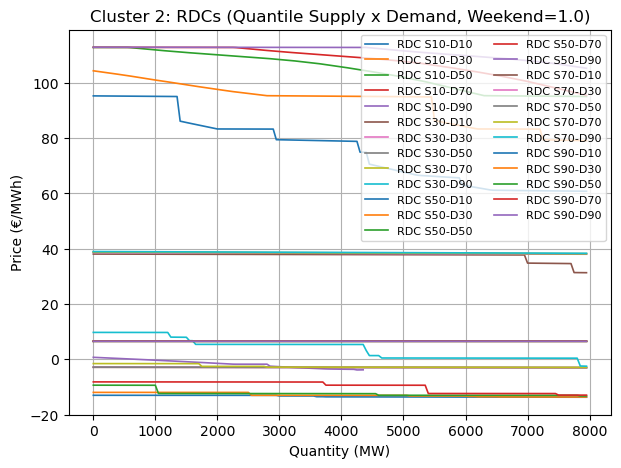

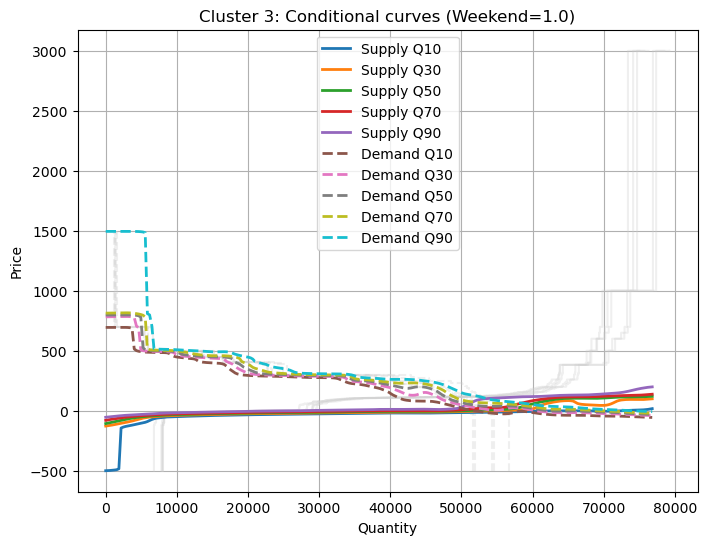

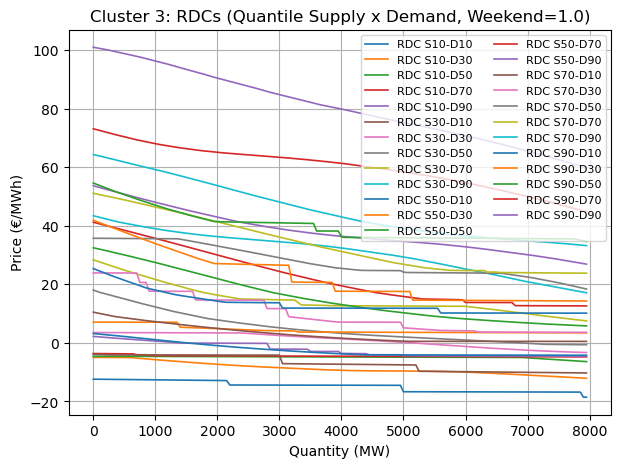

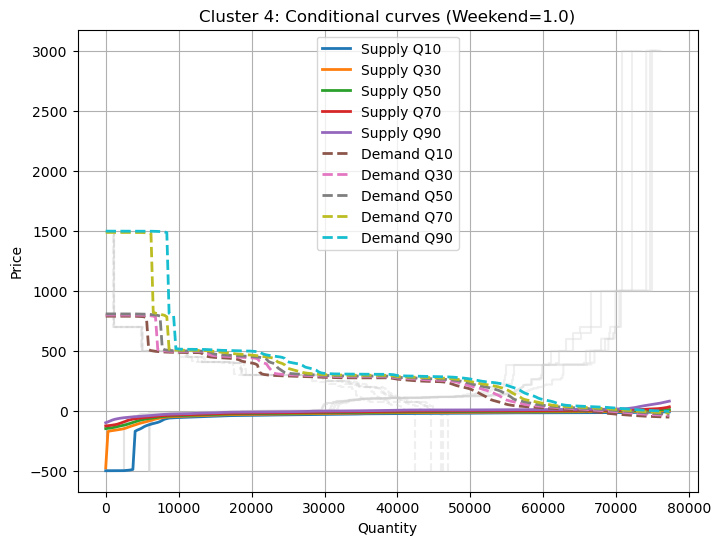

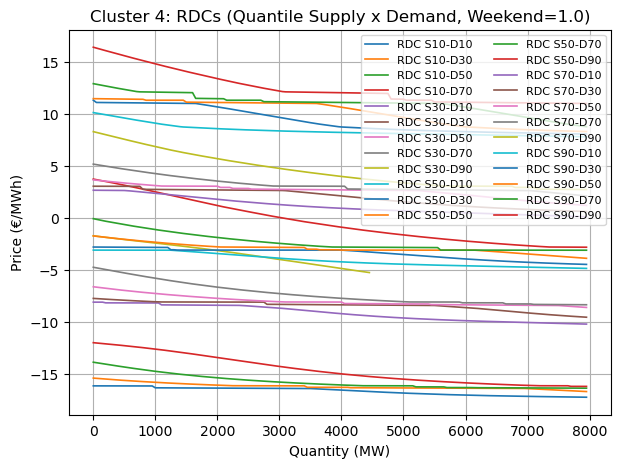

In [111]:
# 맥락 예시: T=30°C, F=28000 MW, Weekend=True
T_ctx = 30.0
F_ctx = 28000.0
W_ctx = 1.0   # 주말

for c in clusters:
    members = [cur for cur in supply_curves if cur["Cluster"] == c]
    if not members:
        continue

    # Q,P,T,F,W 포인트 수집
    pts = collect_points_QPTFW(members, context_df=context_df)  # 함수 확장 필요
    

    q_max = np.nanmax([cur["Demand"]["Cumul"].max() for cur in members if not cur["Demand"].empty])
    q_grid = np.linspace(0, q_max, 250)

    # 공급/수요 곡선 추정: 둘 다 quantile
    sup_modal, sup_qtiles_map = modal_and_quantile_curve_QP_TFW(
        pts["sup"], q_grid, T_ctx, F_ctx, W_ctx,
        hq=1500, hT=2.0, hF=800.0, hW=0.5, hp=10.0,
        quantiles=(0.1,0.3,0.5,0.7,0.9))
    dem_modal, dem_qtiles_map = modal_and_quantile_curve_QP_TFW(
        pts["dem"], q_grid, T_ctx, F_ctx, W_ctx,
        hq=1500, hT=2.0, hF=800.0, hW=0.5, hp=10.0,
        quantiles=(0.1,0.3,0.5,0.7,0.9))

    # (A) 수요/공급 곡선 시각화
    plt.figure(figsize=(8,6))
    for cur in members[:5]:
        plt.step(cur["Supply"]["Cumul"], cur["Supply"]["Price"], color="0.8", alpha=0.3)
        plt.step(cur["Demand"]["Cumul"], cur["Demand"]["Price"], color="0.8", alpha=0.3, linestyle="--")

    for qt, scurve in sup_qtiles_map.items():
        plt.plot(q_grid, scurve, lw=2, label=f"Supply Q{int(qt*100)}")
    for qt, dcurve in dem_qtiles_map.items():
        plt.plot(q_grid, dcurve, lw=2, linestyle="--", label=f"Demand Q{int(qt*100)}")

    plt.title(f"Cluster {c}: Conditional curves (Weekend={W_ctx})")
    plt.xlabel("Quantity"); plt.ylabel("Price"); plt.grid(True); plt.legend(); plt.show()

    # (B) RDC 조합 계산
    plt.figure(figsize=(7,5))
    for sqt, scurve in sup_qtiles_map.items():
        for dqt, dcurve in dem_qtiles_map.items():
            rdc_pts = rdc_from_modal_curves(q_grid, scurve, dcurve, wf_offer_grid)
            if rdc_pts:
                qv, pv = zip(*rdc_pts)
                plt.plot(qv, pv, lw=1.2, label=f"RDC S{int(sqt*100)}-D{int(dqt*100)}")

    plt.title(f"Cluster {c}: RDCs (Quantile Supply x Demand, Weekend={W_ctx})")
    plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
    plt.grid(True); plt.legend(ncol=2, fontsize=8); plt.show()


In [124]:
from sklearn.neighbors import NearestNeighbors


In [131]:
def silverman_bandwidth(x):
    n = len(x)
    sigma = np.std(x, ddof=1)
    if n <= 1 or sigma == 0:
        return 1.0   # 데이터가 너무 적거나 분산 0일 때 fallback
    return 1.06 * sigma * n ** (-1/5)


def modal_and_quantile_curve_QP_TFW(points, q_grid, T_ctx, F_ctx, W_ctx,
                                    quantiles=(0.5,), p_res=400):
    """
    KDE 기반 modal + quantile 곡선 추정 (공급/수요)
    Silverman bandwidth 자동 추정 추가
    """
    if points is None or len(points) == 0:
        return None, {}

    Q, P, T, F, W = points.T

    # === Silverman bandwidth 자동 계산 ===
    hq = silverman_bandwidth(Q)
    hT = silverman_bandwidth(T)
    hF = silverman_bandwidth(F)
    hp = silverman_bandwidth(P)
    # W는 이진값이므로 작은 상수 또는 변동성 기반
    hW = 0.5 * np.sqrt(np.var(W)) if np.var(W) > 0 else 0.5

    modal_p = []
    qtile_map = {qt: [] for qt in quantiles}

    p_min, p_max = np.nanmin(P), np.nanmax(P)
    p_axis = np.linspace(p_min, p_max, p_res)

    for q in q_grid:
        # 컨텍스트 가중치
        w_ctx = (
            gaussian_kernel(q - Q, hq) *
            gaussian_kernel(T - T_ctx, hT) *
            gaussian_kernel(F - F_ctx, hF) *
            gaussian_kernel(W - W_ctx, hW)
        )

        if np.all(w_ctx == 0):
            modal_p.append(np.nan)
            for qt in quantiles:
                qtile_map[qt].append(np.nan)
            continue

        # 가격축 KDE
        kde_vals = []
        for p0 in p_axis:
            kern = gaussian_kernel(P - p0, hp)
            kde_vals.append(np.sum(w_ctx * kern))
        kde_vals = np.array(kde_vals)

        # Modal
        modal_p.append(p_axis[np.argmax(kde_vals)])

        # 분위수
        cdf = np.cumsum(kde_vals)
        cdf = cdf / cdf[-1]
        for qt in quantiles:
            qtile_map[qt].append(np.interp(qt, cdf, p_axis))

    modal_p = np.array(modal_p)
    for qt in quantiles:
        qtile_map[qt] = np.array(qtile_map[qt])

    return modal_p, qtile_map


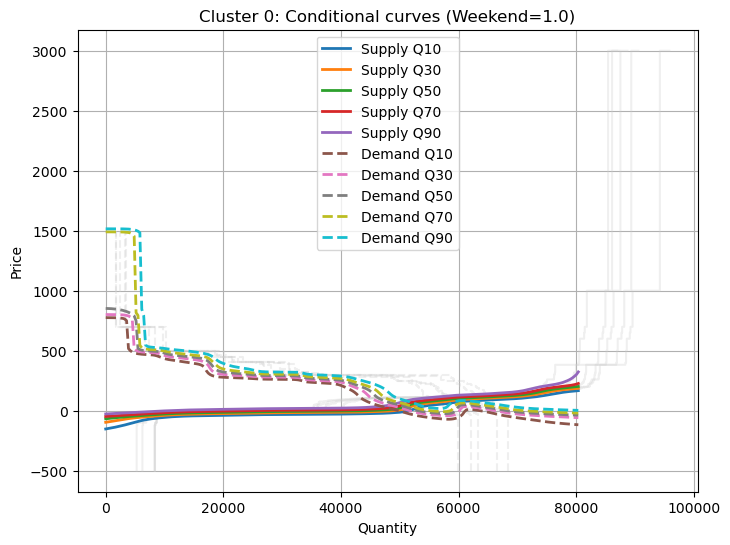

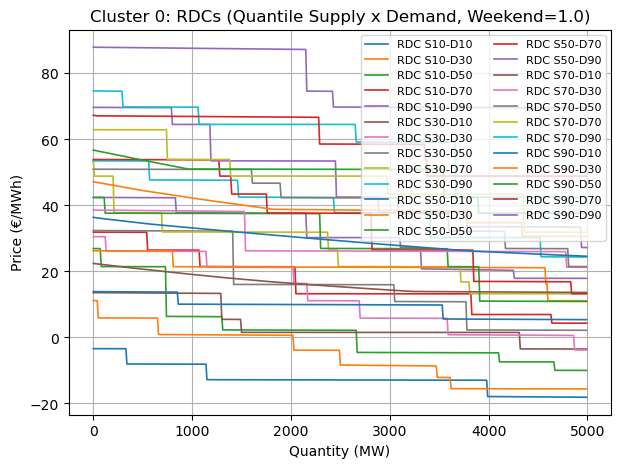

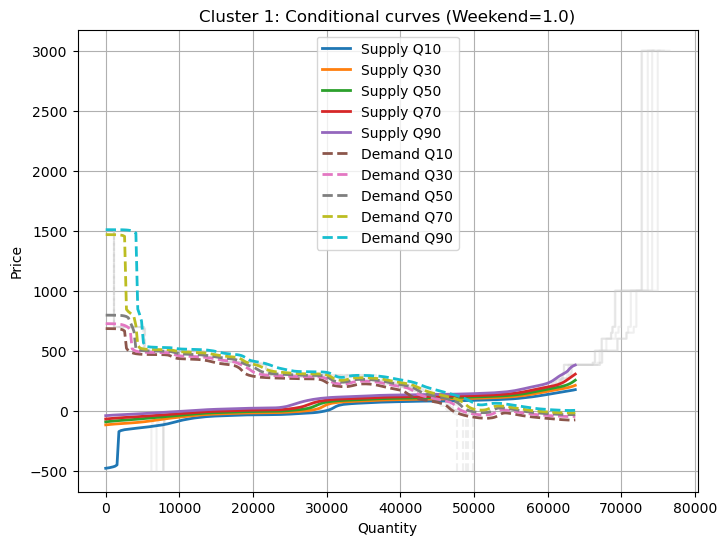

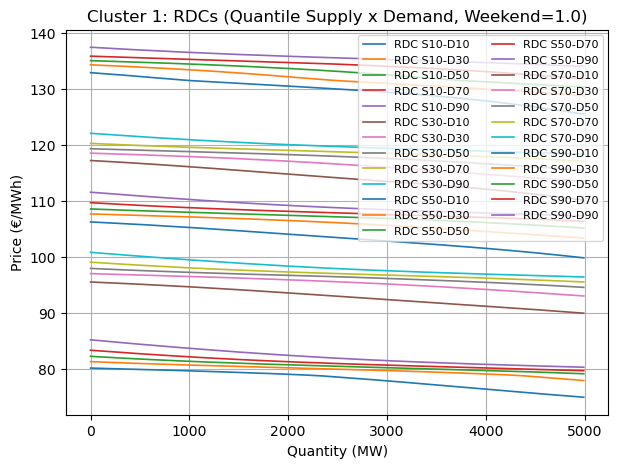

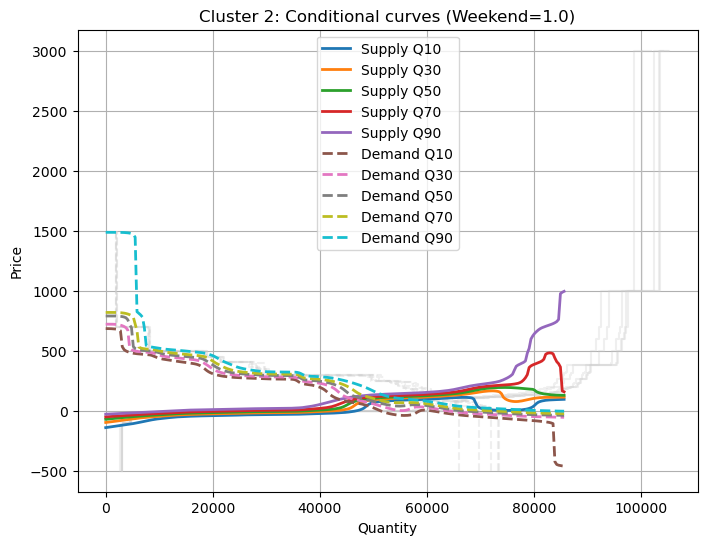

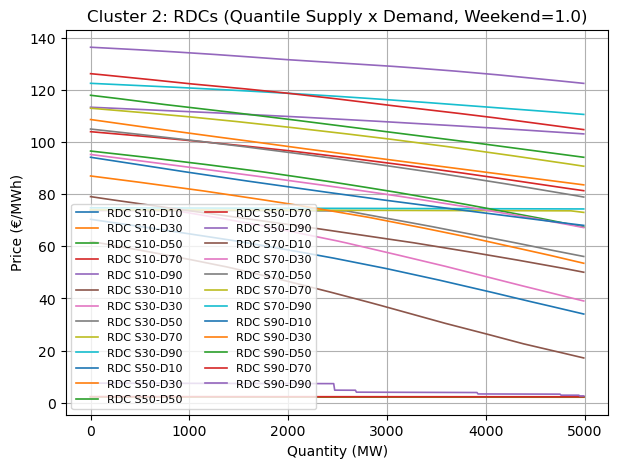

KeyboardInterrupt: 

In [134]:
# 맥락 예시: T=30°C, F=28000 MW, Weekend=True
T_ctx = 30.0
F_ctx = 28000.0
W_ctx = 1.0   # 주말

for c in clusters:
    members = [cur for cur in supply_curves if cur["Cluster"] == c]
    if not members:
        continue

    # Q,P,T,F,W 포인트 수집
    pts = collect_points_QPTFW(members, context_df=context_df)  # 함수 확장 필요
    

    q_max = np.nanmax([cur["Demand"]["Cumul"].max() for cur in members if not cur["Demand"].empty])
    q_grid = np.linspace(0, q_max, 250)

    # 공급/수요 곡선 추정: 둘 다 quantile
    sup_modal, sup_qtiles_map = modal_and_quantile_curve_QP_TFW(
        pts["sup"], q_grid, T_ctx, F_ctx, W_ctx,
        quantiles=(0.1,0.3,0.5,0.7,0.9))
    dem_modal, dem_qtiles_map = modal_and_quantile_curve_QP_TFW(
        pts["dem"], q_grid, T_ctx, F_ctx, W_ctx,
        quantiles=(0.1,0.3,0.5,0.7,0.9))

    # (A) 수요/공급 곡선 시각화
    plt.figure(figsize=(8,6))
    for cur in members[:5]:
        plt.step(cur["Supply"]["Cumul"], cur["Supply"]["Price"], color="0.8", alpha=0.3)
        plt.step(cur["Demand"]["Cumul"], cur["Demand"]["Price"], color="0.8", alpha=0.3, linestyle="--")

    for qt, scurve in sup_qtiles_map.items():
        plt.plot(q_grid, scurve, lw=2, label=f"Supply Q{int(qt*100)}")
    for qt, dcurve in dem_qtiles_map.items():
        plt.plot(q_grid, dcurve, lw=2, linestyle="--", label=f"Demand Q{int(qt*100)}")

    plt.title(f"Cluster {c}: Conditional curves (Weekend={W_ctx})")
    plt.xlabel("Quantity"); plt.ylabel("Price"); plt.grid(True); plt.legend(); plt.show()

    # (B) RDC 조합 계산
    plt.figure(figsize=(7,5))
    for sqt, scurve in sup_qtiles_map.items():
        for dqt, dcurve in dem_qtiles_map.items():
            rdc_pts = rdc_from_modal_curves(q_grid, scurve, dcurve, wf_offer_grid)
            if rdc_pts:
                qv, pv = zip(*rdc_pts)
                plt.plot(qv, pv, lw=1.2, label=f"RDC S{int(sqt*100)}-D{int(dqt*100)}")

    plt.title(f"Cluster {c}: RDCs (Quantile Supply x Demand, Weekend={W_ctx})")
    plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
    plt.grid(True); plt.legend(ncol=2, fontsize=8); plt.show()


시도 3

In [135]:
# ---------- 1) 보조 함수 ----------

def collect_points_QPTFW(members, context_df):
    """
    각 공급/수요곡선 멤버에서 (Q,P,T,F,W) 데이터를 수집
    """
    sup_points, dem_points = [], []
    for cur in members:
        dt = cur["Datetime"]
        row = context_df[context_df["Datetime"] == dt]
        if row.empty:
            continue
        T = float(row["T"].values[0])
        F = float(row["value"].values[0])
        W = 1.0 if row["IsWeekend"].values[0] else 0.0

        # 공급곡선
        s = cur["Supply"]
        if not s.empty:
            for q, p in zip(s["Cumul"].values, s["Price"].values):
                sup_points.append((q, p, T, F, W))

        # 수요곡선
        d = cur["Demand"]
        if not d.empty:
            for q, p in zip(d["Cumul"].values, d["Price"].values):
                dem_points.append((q, p, T, F, W))

    return {"sup": np.array(sup_points), "dem": np.array(dem_points)}


def gaussian_kernel(x, h):
    return np.exp(-0.5 * (x / h) ** 2) / (np.sqrt(2 * np.pi) * h)


def silverman_bandwidth(x):
    n = len(x)
    sigma = np.std(x, ddof=1)
    if n <= 1 or sigma == 0:
        return 1.0
    return 1.06 * sigma * n ** (-1 / 5)


def modal_and_quantile_curve_QP_TFW(points, q_grid, T_ctx, F_ctx, W_ctx,
                                    quantiles=(0.5,), p_res=400):
    """
    KDE 기반 modal + quantile 곡선 추정 (공급/수요)
    """
    if points is None or len(points) == 0:
        return None, {}

    Q, P, T, F, W = points.T

    # === Silverman 자동 bandwidth 추정 ===
    hq = silverman_bandwidth(Q)
    hT = silverman_bandwidth(T)
    hF = silverman_bandwidth(F)
    hp = silverman_bandwidth(P)
    hW = 0.5 * np.sqrt(np.var(W)) if np.var(W) > 0 else 0.5

    modal_p = []
    qtile_map = {qt: [] for qt in quantiles}

    p_min, p_max = np.nanmin(P), np.nanmax(P)
    p_axis = np.linspace(p_min, p_max, p_res)

    for q in q_grid:
        # 컨텍스트 가중치
        w_ctx = (
            gaussian_kernel(q - Q, hq) *
            gaussian_kernel(T - T_ctx, hT) *
            gaussian_kernel(F - F_ctx, hF) *
            gaussian_kernel(W - W_ctx, hW)
        )
        if np.all(w_ctx == 0):
            modal_p.append(np.nan)
            for qt in quantiles:
                qtile_map[qt].append(np.nan)
            continue

        # 가격축 KDE
        kde_vals = []
        for p0 in p_axis:
            kern = gaussian_kernel(P - p0, hp)
            kde_vals.append(np.sum(w_ctx * kern))
        kde_vals = np.array(kde_vals)

        modal_p.append(p_axis[np.argmax(kde_vals)])  # Modal
        cdf = np.cumsum(kde_vals) / np.sum(kde_vals)
        for qt in quantiles:
            qtile_map[qt].append(np.interp(qt, cdf, p_axis))

    return np.array(modal_p), {qt: np.array(vals) for qt, vals in qtile_map.items()}


C:\Users\symply_jina\AppData\Local\Temp\ipykernel_42032\2910575614.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.grid(True); plt.legend(); plt.show()


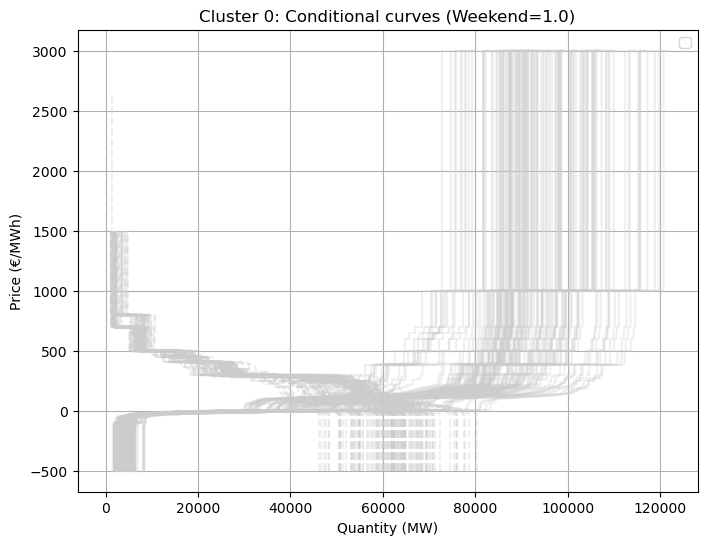

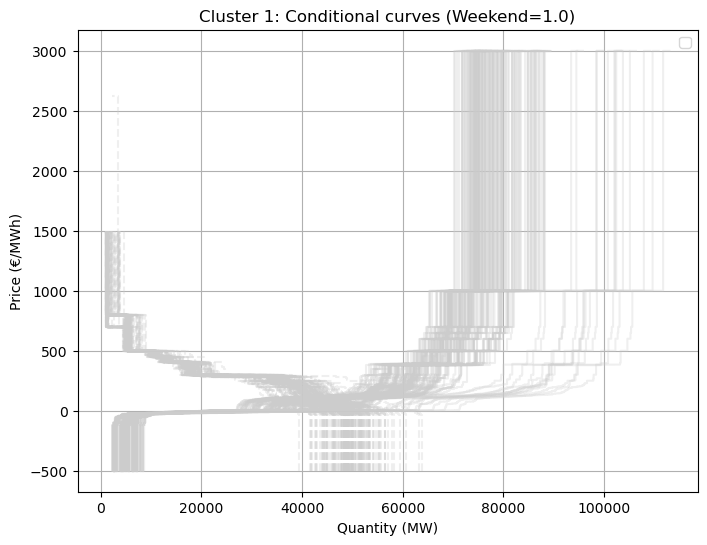

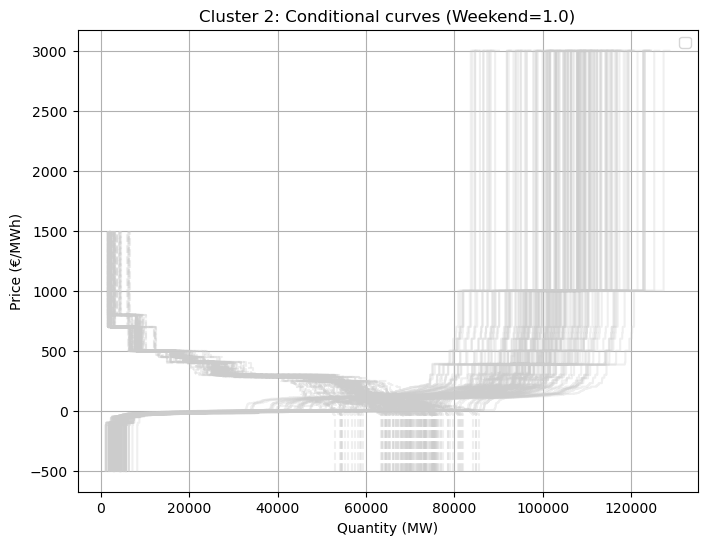

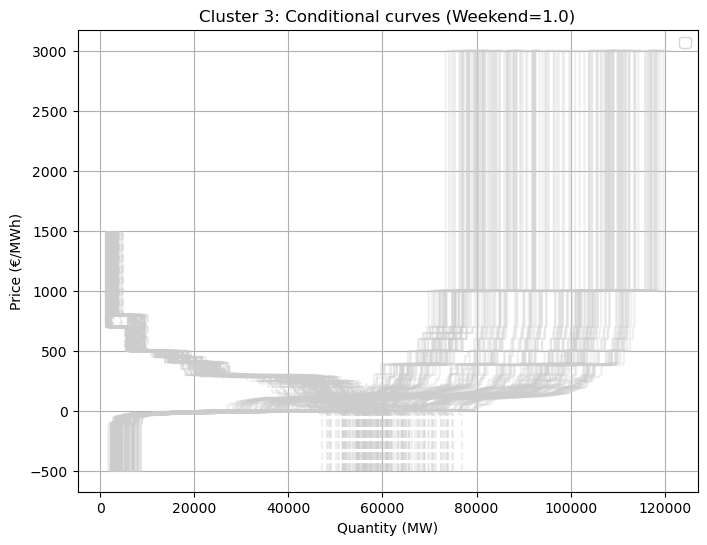

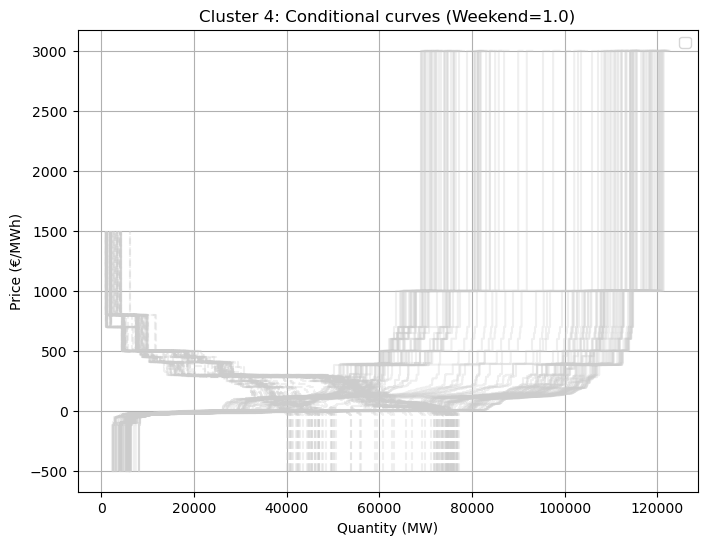

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


In [160]:
# 맥락 예시 (주말/평일 여부 포함)
T_ctx = 30.0
F_ctx = 28000.0
W_ctx = 1.0   # 주말=1.0, 평일=0.0

q_grid = np.linspace(20000, 80000, 250)

for c in clusters:  # 클러스터별 반복
    members = [cur for cur in supply_curves if cur["Cluster"] == c]
    if not members:
        continue

    # # Q,P,T,F,W 포인트 수집
    # pts = collect_points_QPTFW(members, context_df=context_df)

    # # 공급/수요 KDE 기반 modal+quantile
    # sup_modal, sup_qtiles = modal_and_quantile_curve_QP_TFW(
    #     pts["sup"], q_grid, T_ctx, F_ctx, W_ctx, quantiles=(0.1, 0.5, 0.9))
    # dem_modal, dem_qtiles = modal_and_quantile_curve_QP_TFW(
    #     pts["dem"], q_grid, T_ctx, F_ctx, W_ctx, quantiles=(0.1, 0.5, 0.9))

    # 시각화
    plt.figure(figsize=(8,6))
    for cur in members[:]:
        plt.step(cur["Supply"]["Cumul"], cur["Supply"]["Price"], color="0.8", alpha=0.3)
        plt.step(cur["Demand"]["Cumul"], cur["Demand"]["Price"], color="0.8", alpha=0.3, linestyle="--")

    # plt.plot(q_grid, sup_modal, color="blue", lw=2, label="Supply modal")
    # for qt, curve in sup_qtiles.items():
    #     plt.plot(q_grid, curve, "--", label=f"Supply Q{int(qt*100)}")

    # plt.plot(q_grid, dem_modal, color="red", lw=2, label="Demand modal")
    # for qt, curve in dem_qtiles.items():
    #     plt.plot(q_grid, curve, "--", label=f"Demand Q{int(qt*100)}")

    plt.title(f"Cluster {c}: Conditional curves (Weekend={W_ctx})")
    plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
    plt.grid(True); plt.legend(); plt.show()


In [162]:
import numpy as np
from sklearn.isotonic import IsotonicRegression

def _gauss(u):  # 표준 가우스 커널
    return np.exp(-0.5*u*u) / np.sqrt(2*np.pi)

def _effective_n(w):
    s1 = np.sum(w); s2 = np.sum(w*w)
    return (s1*s1)/s2 if s2>0 else 0.0

def _mono_fix(y, increasing=True):
    m = np.isfinite(y)
    if m.sum() < 4:
        return y
    ir = IsotonicRegression(increasing=increasing, out_of_bounds='clip')
    y_fit = ir.fit_transform(np.arange(len(y))[m], y[m])
    z = y.copy(); z[m] = y_fit
    return z

def modal_and_quantile_curve_QP_TFW_robust(points, q_grid, T_ctx, F_ctx, W_ctx,
                                           quantiles=(0.5,), p_res=401,
                                           kind='demand',
                                           min_neff=80, inflate=1.3):
    """
    KDE 기반 조건부 P(Q) 추정 (강건/단조 보정)
    kind: 'supply' -> 단조증가, 'demand' -> 단조감소
    """
    if points is None or len(points)==0:
        return None, {}

    Q, P, T, F, W = points.T.astype(float)

    # --- 스케일 표준화 (Q,T,F만 z-score) ---
    def z(x):
        s = np.std(x)
        return (x - np.mean(x)) / (s if s>0 else 1.0)
    Qz, Tz, Fz = z(Q), z(T), z(F)
    qz_ctx, tz_ctx, fz_ctx = z(q_grid), (T_ctx - np.mean(T))/ (np.std(T) or 1.0), (F_ctx - np.mean(F))/ (np.std(F) or 1.0)

    modal, qtiles = [], {qt: [] for qt in quantiles}

    for qi, q in enumerate(q_grid):
        # 컨텍스트 가중치 (표준화 공간)
        w = _gauss((Qz - qz_ctx[qi])) * _gauss(Tz - tz_ctx) * _gauss(Fz - fz_ctx) * _gauss((W - W_ctx)/0.4)
        # 유효표본 확인 → 너무 작으면 완화(밴드확대)
        neff = _effective_n(w)
        if neff < min_neff:
            w = _gauss((Qz - qz_ctx[qi])/inflate) * _gauss((Tz - tz_ctx)/inflate) * _gauss((Fz - fz_ctx)/inflate) * _gauss((W - W_ctx)/(0.4*inflate))
            neff = _effective_n(w)

        if neff <= 5:
            modal.append(np.nan)
            for qt in quantiles: qtiles[qt].append(np.nan)
            continue

        # 가중 분위수로 가격축 제한 (꼬리 제거)
        m = w>0
        Pw, Ww = P[m], w[m]
        if len(Pw) < 5:
            modal.append(np.nan)
            for qt in quantiles: qtiles[qt].append(np.nan)
            continue
        # 가중 분위수 계산
        order = np.argsort(Pw)
        Pw_s, Ww_s = Pw[order], Ww[order]
        c = np.cumsum(Ww_s); c /= c[-1]
        p_lo = np.interp(0.01, c, Pw_s)
        p_hi = np.interp(0.99, c, Pw_s)
        p_axis = np.linspace(p_lo, p_hi, p_res)

        # 가격축 KDE (가중)
        # Silverman hp 대신 표준화-불필요, 축 자체에서 h는 자동으로 p축 범위/분해능로 흡수
        # 밀도 ∝ sum w * φ((P - p)/hp) ; 여기선 hp를 p축 분해능으로 대체
        # 수치 안정성을 위해 벡터화
        dif = (Pw_s[:,None] - p_axis[None,:])
        # hp 적당히 (가격 단위가 크면 10~20; 상대적이면 np.ptp(P)/100 등)
        hp = max(np.ptp(Pw_s)/80, 5.0)
        kde = (Ww_s[:,None] * _gauss(dif/hp)).sum(axis=0)

        # modal
        modal.append(p_axis[np.argmax(kde)])
        # 분위수
        cdf = np.cumsum(kde); 
        if cdf[-1] > 0:
            cdf /= cdf[-1]
            for qt in quantiles:
                qtiles[qt].append(np.interp(qt, cdf, p_axis))
        else:
            for qt in quantiles:
                qtiles[qt].append(np.nan)

    modal = np.array(modal)
    for qt in quantiles:
        qtiles[qt] = np.array(qtiles[qt])

    # --- 단조 보정 ---
    if kind == 'supply':
        modal = _mono_fix(modal, increasing=True)
        for qt in quantiles: qtiles[qt] = _mono_fix(qtiles[qt], increasing=True)
    else:  # demand
        modal = _mono_fix(modal, increasing=False)
        for qt in quantiles: qtiles[qt] = _mono_fix(qtiles[qt], increasing=False)

    return modal, qtiles


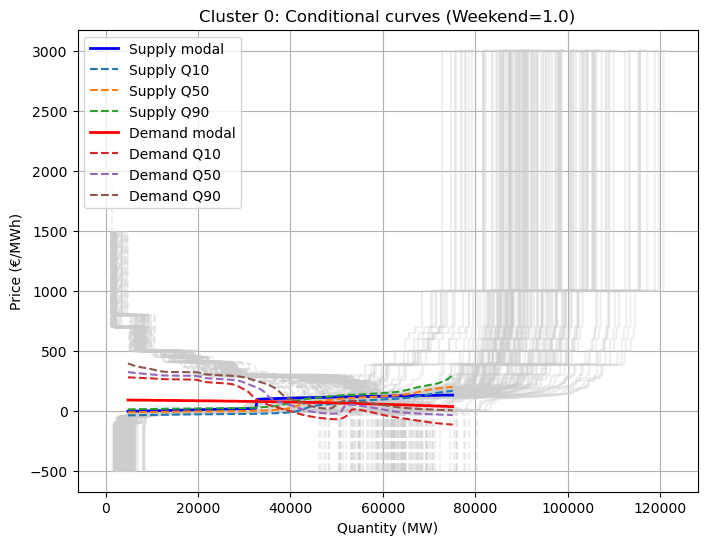

KeyboardInterrupt: 

In [163]:
# 맥락 예시 (주말/평일 여부 포함)
T_ctx = 30.0
F_ctx = 28000.0
W_ctx = 1.0   # 주말=1.0, 평일=0.0

q_grid = np.linspace(20000, 80000, 250)

for c in clusters:  # 클러스터별 반복
    members = [cur for cur in supply_curves if cur["Cluster"] == c]
    if not members:
        continue

    # Q,P,T,F,W 포인트 수집
    pts = collect_points_QPTFW(members, context_df=context_df)

    # grid는 S/D 공통 교집합 범위(혹은 적당히)로
    q_min =  max(np.nanpercentile(pts["sup"][:,0], 1), np.nanpercentile(pts["dem"][:,0], 1))
    q_max =  min(np.nanpercentile(pts["sup"][:,0],99), np.nanpercentile(pts["dem"][:,0],99))
    q_grid = np.linspace(q_min, q_max, 250)

    # 공급(단조↑) / 수요(단조↓)
    sup_modal, sup_q = modal_and_quantile_curve_QP_TFW_robust(pts["sup"], q_grid, T_ctx, F_ctx, W_ctx,
                                                            quantiles=(0.1,0.5,0.9), kind='supply')
    dem_modal, dem_q  = modal_and_quantile_curve_QP_TFW_robust(pts["dem"], q_grid, T_ctx, F_ctx, W_ctx,
                                                            quantiles=(0.1,0.5,0.9), kind='demand')


    # 시각화
    plt.figure(figsize=(8,6))
    for cur in members[:]:
        plt.step(cur["Supply"]["Cumul"], cur["Supply"]["Price"], color="0.8", alpha=0.3)
        plt.step(cur["Demand"]["Cumul"], cur["Demand"]["Price"], color="0.8", alpha=0.3, linestyle="--")

    plt.plot(q_grid, sup_modal, color="blue", lw=2, label="Supply modal")
    for qt, curve in sup_qtiles.items():
        plt.plot(q_grid, curve, "--", label=f"Supply Q{int(qt*100)}")

    plt.plot(q_grid, dem_modal, color="red", lw=2, label="Demand modal")
    for qt, curve in dem_qtiles.items():
        plt.plot(q_grid, curve, "--", label=f"Demand Q{int(qt*100)}")

    plt.title(f"Cluster {c}: Conditional curves (Weekend={W_ctx})")
    plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
    plt.grid(True); plt.legend(); plt.show()


expectation

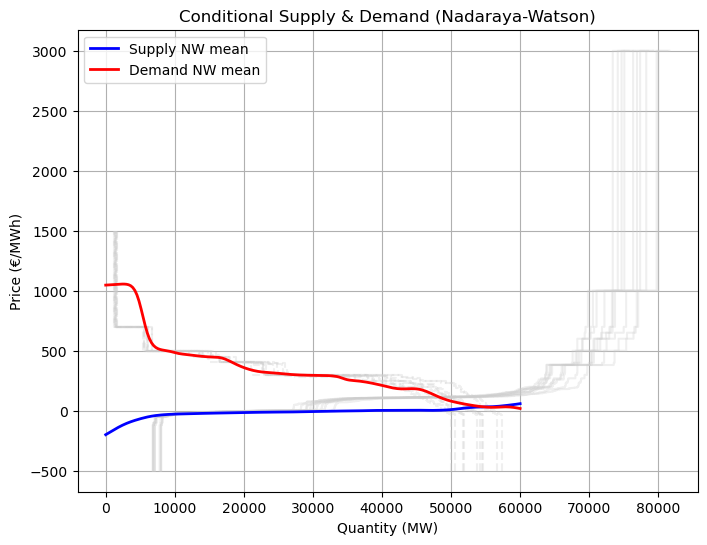

In [150]:
def gaussian_kernel(x, h):
    return np.exp(-0.5*(x/h)**2) / (np.sqrt(2*np.pi)*h)

def nadaraya_watson_curve(points, q_grid, T_ctx, F_ctx, W_ctx,
                          hq=1500, hT=2.0, hF=800.0, hW=0.5):
    """
    Nadaraya–Watson kernel regression으로 E[P | Q, T, F, W] 추정
    points: (Q,P,T,F,W) 배열
    q_grid: Quantity grid
    ctx: 주어진 (T,F,W) 조건
    """
    if points is None or len(points) == 0:
        return None

    Q, P, T, F, W = points.T
    est_curve = []

    for q in q_grid:
        # 각 데이터포인트에 대한 가중치
        w = (
            gaussian_kernel(q - Q, hq) *
            gaussian_kernel(T - T_ctx, hT) *
            gaussian_kernel(F - F_ctx, hF) *
            gaussian_kernel(W - W_ctx, hW)
        )
        if np.sum(w) == 0:
            est_curve.append(np.nan)
        else:
            est_curve.append(np.sum(w * P) / np.sum(w))  # weighted mean

    return np.array(est_curve)

# === 사용 예시 ===
pts = collect_points_QPTFW(members, context_df)   # (Q,P,T,F,W) 추출
q_grid = np.linspace(0, 60000, 200)

sup_curve = nadaraya_watson_curve(pts["sup"], q_grid, T_ctx=30, F_ctx=28000, W_ctx=1.0)
dem_curve = nadaraya_watson_curve(pts["dem"], q_grid, T_ctx=30, F_ctx=28000, W_ctx=1.0)

plt.figure(figsize=(8,6))
for cur in members[:10]:  # 원본 회색
    plt.step(cur["Supply"]["Cumul"], cur["Supply"]["Price"], color="0.8", alpha=0.3)
    plt.step(cur["Demand"]["Cumul"], cur["Demand"]["Price"], color="0.8", alpha=0.3, linestyle="--")
plt.plot(q_grid, sup_curve, color="blue", lw=2, label="Supply NW mean")
plt.plot(q_grid, dem_curve, color="red", lw=2, label="Demand NW mean")
plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
plt.title("Conditional Supply & Demand (Nadaraya-Watson)")
plt.legend(); plt.grid(True); plt.show()


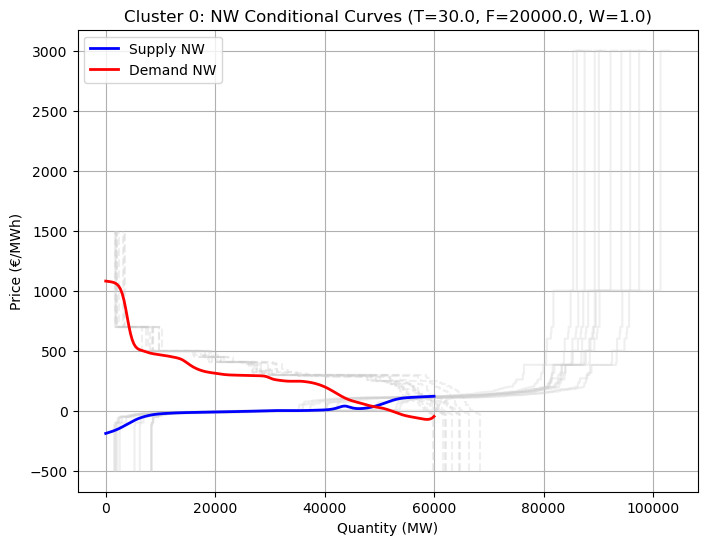

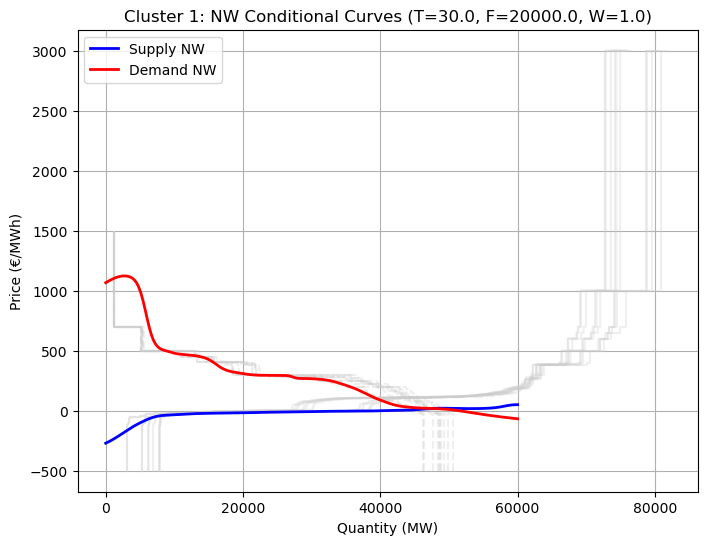

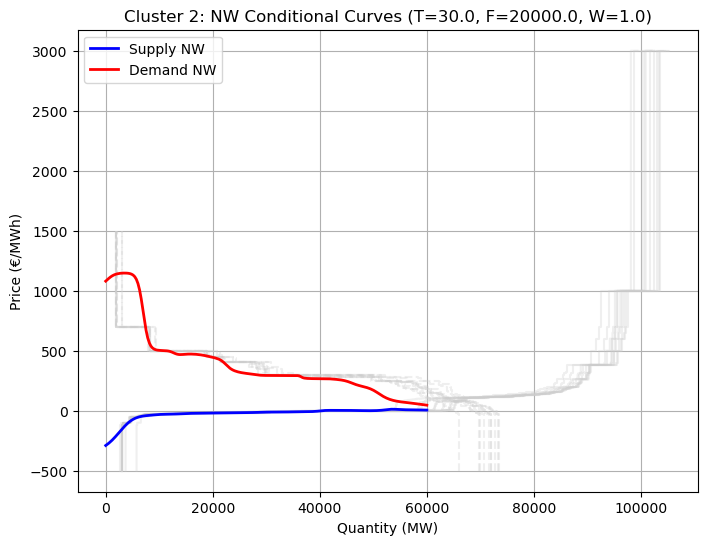

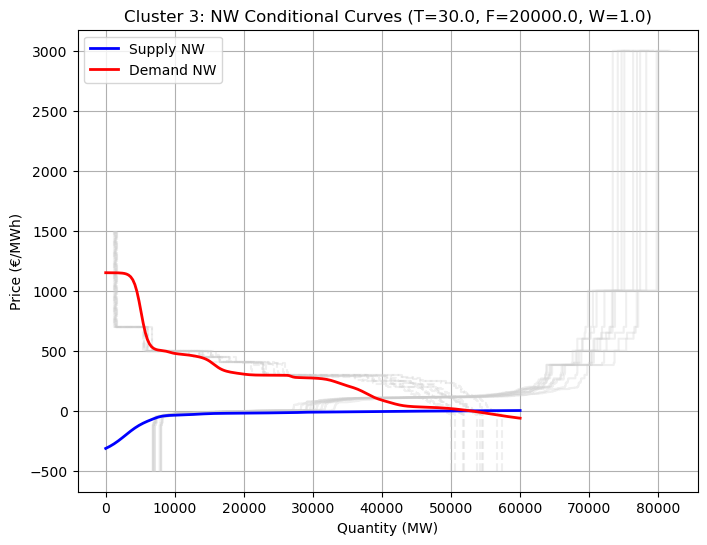

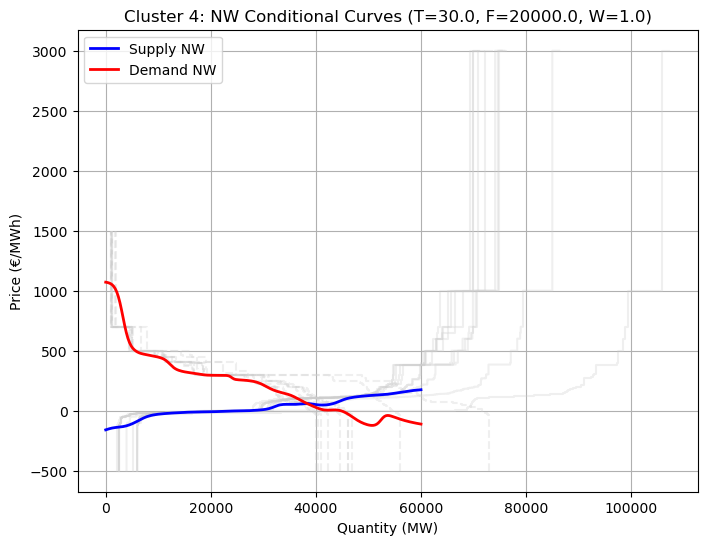

In [153]:
# ===== 1. Nadaraya–Watson 커널 회귀 함수 =====
def gaussian_kernel(x, h):
    return np.exp(-0.5*(x/h)**2) / (np.sqrt(2*np.pi)*h)

def nadaraya_watson_curve(points, q_grid, T_ctx, F_ctx, W_ctx,
                          hq=1500, hT=2.0, hF=800.0, hW=0.5):
    """조건부 NW 커널 회귀로 E[P|Q,T,F,W] 추정"""
    if points is None or len(points) == 0:
        return None

    Q, P, T, F, W = points.T
    est_curve = []

    for q in q_grid:
        w = (
            gaussian_kernel(q - Q, hq) *
            gaussian_kernel(T - T_ctx, hT) *
            gaussian_kernel(F - F_ctx, hF) *
            gaussian_kernel(W - W_ctx, hW)
        )
        if np.sum(w) == 0:
            est_curve.append(np.nan)
        else:
            est_curve.append(np.sum(w * P) / np.sum(w))  # weighted mean

    return np.array(est_curve)


# ===== 2. 클러스터별 커브 추정 =====
q_grid = np.linspace(0, 60000, 200)   # Q grid
T_ctx, F_ctx, W_ctx = 30.0, 20000.0, 1.0   # 예시 맥락 (주말)

for c in sorted(set(cur["Cluster"] for cur in supply_curves if cur["Cluster"] is not None)):
    members = [cur for cur in supply_curves if cur["Cluster"] == c]
    if not members:
        continue

    # Q,P,T,F,W 포인트 수집
    pts = collect_points_QPTFW(members, context_df)

    # NW 기반 추정
    sup_curve = nadaraya_watson_curve(pts["sup"], q_grid, T_ctx, F_ctx, W_ctx)
    dem_curve = nadaraya_watson_curve(pts["dem"], q_grid, T_ctx, F_ctx, W_ctx)

    # === 시각화 ===
    plt.figure(figsize=(8,6))
    for cur in members[:10]:  # 원본 회색 곡선
        plt.step(cur["Supply"]["Cumul"], cur["Supply"]["Price"], color="0.8", alpha=0.3)
        plt.step(cur["Demand"]["Cumul"], cur["Demand"]["Price"], color="0.8", alpha=0.3, linestyle="--")

    if sup_curve is not None:
        plt.plot(q_grid, sup_curve, color="blue", lw=2, label="Supply NW")
    if dem_curve is not None:
        plt.plot(q_grid, dem_curve, color="red", lw=2, label="Demand NW")

    plt.xlabel("Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.title(f"Cluster {c}: NW Conditional Curves (T={T_ctx}, F={F_ctx}, W={W_ctx})")
    plt.legend()
    plt.grid(True)
    plt.show()


In [154]:
def enforce_monotone(curve):
    """
    주어진 곡선을 단조 증가(non-decreasing)하게 보정
    """
    return np.maximum.accumulate(curve)


def modal_and_quantile_curve_QP_TFW_monotone(points, q_grid, T_ctx, F_ctx, W_ctx,
                                             hq=1500, hT=2.0, hF=800.0, hW=0.5, hp=10.0,
                                             quantiles=(0.5,), p_res=400):
    """
    기존 modal_and_quantile_curve_QP_TFW에서
    공급곡선(supply)용으로 monotone 보정을 추가한 버전
    """
    if points is None or len(points) == 0:
        return None, {}

    Q, P, T, F, W = points.T
    modal_p = []
    qtile_map = {qt: [] for qt in quantiles}

    p_min, p_max = np.nanmin(P), np.nanmax(P)
    p_axis = np.linspace(p_min, p_max, p_res)

    for q in q_grid:
        # 컨텍스트 가중치
        w_ctx = (
            gaussian_kernel(q - Q, hq) *
            gaussian_kernel(T - T_ctx, hT) *
            gaussian_kernel(F - F_ctx, hF) *
            gaussian_kernel(W - W_ctx, hW)
        )

        if np.all(w_ctx == 0):
            modal_p.append(np.nan)
            for qt in quantiles:
                qtile_map[qt].append(np.nan)
            continue

        # 가격축 KDE
        kde_vals = []
        for p0 in p_axis:
            kern = gaussian_kernel(P - p0, hp)
            kde_vals.append(np.sum(w_ctx * kern))
        kde_vals = np.array(kde_vals)

        # Modal
        modal_p.append(p_axis[np.argmax(kde_vals)])

        # 분위수
        cdf = np.cumsum(kde_vals)
        cdf = cdf / cdf[-1]
        for qt in quantiles:
            qtile_map[qt].append(np.interp(qt, cdf, p_axis))

    # numpy array 변환
    modal_p = np.array(modal_p)
    for qt in quantiles:
        qtile_map[qt] = np.array(qtile_map[qt])

    # ✅ 단조증가 보정 (supply용)
    modal_p = enforce_monotone(modal_p)
    for qt in quantiles:
        qtile_map[qt] = enforce_monotone(qtile_map[qt])

    return modal_p, qtile_map


In [155]:
# 맥락 예시 (주말/평일 여부 포함)
T_ctx = 30.0
F_ctx = 28000.0
W_ctx = 1.0   # 주말=1.0, 평일=0.0

q_grid = np.linspace(0, 80000, 250)

for c in clusters:  # 클러스터별 반복
    members = [cur for cur in supply_curves if cur["Cluster"] == c]
    if not members:
        continue

    # Q,P,T,F,W 포인트 수집
    pts = collect_points_QPTFW(members, context_df=context_df)

    # 공급/수요 KDE 기반 modal+quantile
    # 공급곡선 (단조증가 보정 적용)
    sup_modal, sup_qtiles_map = modal_and_quantile_curve_QP_TFW_monotone(
        pts["sup"], q_grid, T_ctx, F_ctx, W_ctx,
        hq=1000, hT=2.0, hF=800.0, hW=0.5, hp=5.0,
        quantiles=(0.1,0.3,0.5,0.7,0.9)
    )

    # 수요곡선 (그대로, 단조성 필요 없음)
    dem_modal, dem_qtiles_map = modal_and_quantile_curve_QP_TFW(
        pts["dem"], q_grid, T_ctx, F_ctx, W_ctx,
        hq=1000, hT=2.0, hF=800.0, hW=0.5, hp=5.0,
        quantiles=(0.1,0.3,0.5,0.7,0.9)
    )

    # 시각화
    plt.figure(figsize=(8,6))
    for cur in members[:5]:
        plt.step(cur["Supply"]["Cumul"], cur["Supply"]["Price"], color="0.8", alpha=0.3)
        plt.step(cur["Demand"]["Cumul"], cur["Demand"]["Price"], color="0.8", alpha=0.3, linestyle="--")

    plt.plot(q_grid, sup_modal, color="blue", lw=2, label="Supply modal")
    for qt, curve in sup_qtiles.items():
        plt.plot(q_grid, curve, "--", label=f"Supply Q{int(qt*100)}")

    plt.plot(q_grid, dem_modal, color="red", lw=2, label="Demand modal")
    for qt, curve in dem_qtiles.items():
        plt.plot(q_grid, curve, "--", label=f"Demand Q{int(qt*100)}")

    plt.title(f"Cluster {c}: Conditional curves (Weekend={W_ctx})")
    plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
    plt.grid(True); plt.legend(); plt.show()


TypeError: modal_and_quantile_curve_QP_TFW() got an unexpected keyword argument 'hq'

### Test

In [152]:
files = glob.glob("filteredcurve_202507*.csv")
df_list = []
for fn in files:
    temp = pd.read_csv(fn, encoding="utf-8-sig")

    # 파일명에서 날짜 추출
    date_str = fn.split("_")[-1].split(".")[0]   # "20250720"
    temp["Date"] = pd.to_datetime(date_str, format="%Y%m%d")

    # 공급곡선의 Period → Hour 변환 (1~24 → 0~23)
    temp = temp.dropna(subset=["Time Period"])
    temp["Hour"] = temp["Time Period"].astype(int)

    # Datetime 만들기 (같은 포맷: "20250720 0")
    temp["Datetime"] = temp["Date"].dt.strftime("%Y%m%d") + " " + temp["Hour"].astype(str)

    df_list.append(temp)

df_supply = pd.concat(df_list, ignore_index=True)

print(df_supply[["Date", "Hour", "Datetime"]].head())

        Date  Hour    Datetime
0 2025-07-01     1  20250701 1
1 2025-07-01     1  20250701 1
2 2025-07-01     1  20250701 1
3 2025-07-01     1  20250701 1
4 2025-07-01     1  20250701 1


        Datetime     T    value  Weekday  IsWeekend  Cluster
696   20250730 1  20.6  26945.0        2      False        1
697   20250730 2  19.3  25405.5        2      False        1
698   20250730 3  18.3  24266.3        2      False        1
699   20250730 4  17.2  23671.3        2      False        1
700   20250730 5  16.8  23400.8        2      False        1
701   20250730 6  15.9  23753.0        2      False        1
702   20250730 7  15.8  25944.3        2      False        1
703   20250730 8  18.4  28016.0        2      False        1
704   20250730 9  22.4  29209.8        2      False        2
705  20250730 10  24.2  29590.8        2      False        2
706  20250730 11  25.7  29846.0        2      False        2
707  20250730 12  28.1  30070.0        2      False        2
708  20250730 13  30.0  30380.0        2      False        2
709  20250730 14  31.1  30809.3        2      False        2
710  20250730 15  32.8  30751.3        2      False        2
711  20250730 16  33.3  

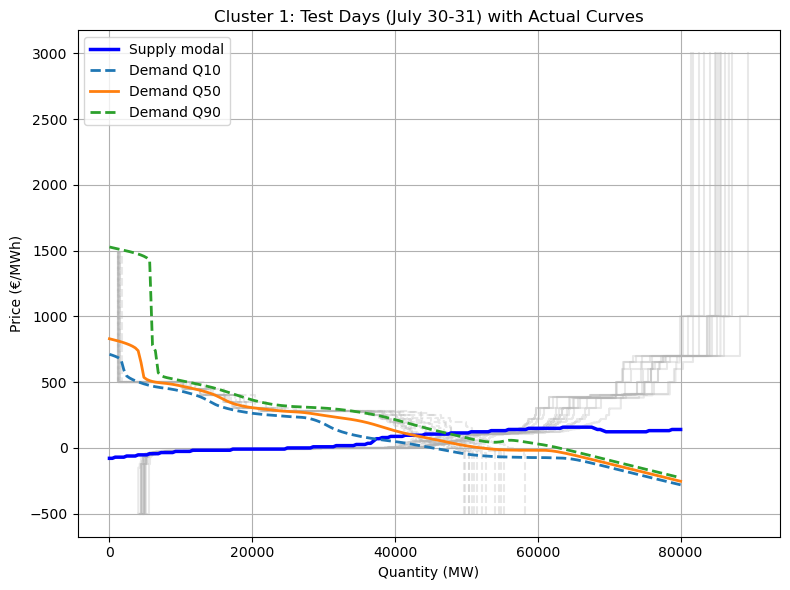

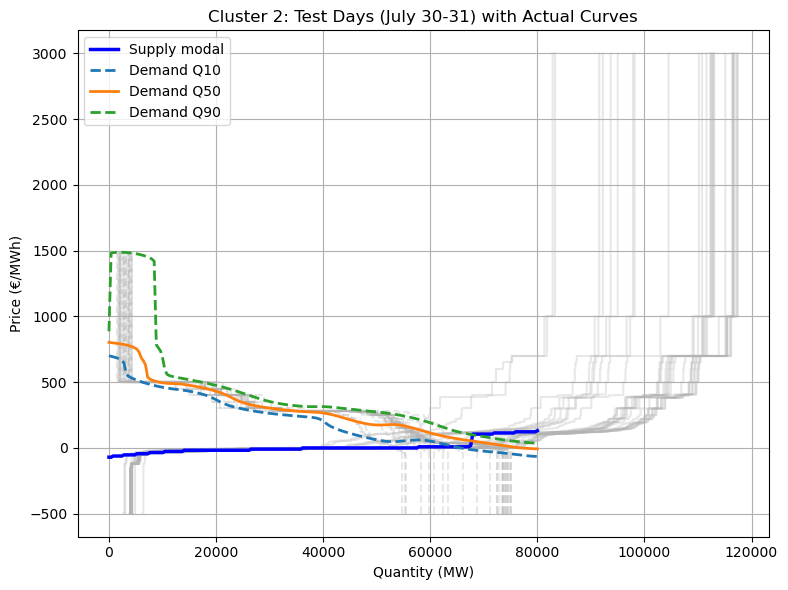

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 테스트 데이터 불러오기
files = ["test_filteredcurve_20250730.csv", "test_filteredcurve_20250731.csv"]
test_list = []
for fn in files:
    tmp = pd.read_csv(fn, encoding="utf-8-sig")

    # 파일명에서 날짜 추출
    date_str = fn.split("_")[-1].split(".")[0]   # e.g., "20250730"
    tmp["Date"] = pd.to_datetime(date_str, format="%Y%m%d")

    # 공급곡선의 Period → Hour 변환 (1~24 → 1~24)
    tmp = tmp.dropna(subset=["Time Period"])
    tmp["Hour"] = tmp["Time Period"].astype(int)

    # Datetime: "20250730 1" 형태
    tmp["Datetime"] = tmp["Date"].dt.strftime("%Y%m%d") + " " + tmp["Hour"].astype(str)

    test_list.append(tmp)

df_test_supply = pd.concat(test_list, ignore_index=True)

# 2. 테스트 피처 준비 (예: 온도, 예측수요, 주말유무)
df_test_features = pd.merge(
    df_forecast[["Datetime","value","Weekday","IsWeekend"]],
    df_weather[["Datetime","T"]],
    on="Datetime", how="inner"
)
df_test_features = df_test_features[df_test_features["Datetime"].isin(df_test_supply["Datetime"].unique())]

# 3. 클러스터 할당
scaled_test = scaler.transform(df_test_features[["T","value"]])
df_test_features["Cluster"] = kmeans.predict(scaled_test)

print(df_test_features[["Datetime","T","value","Weekday","IsWeekend","Cluster"]])

# 4. 클러스터별 KDE 기반 추정 + 실제 테스트일 곡선 비교
q_grid = np.linspace(0, 80000, 200)
wf_offer_grid = np.arange(0, 5000, 10)

for c in df_test_features["Cluster"].unique():
    members = [cur for cur in supply_curves if cur["Cluster"] == c]
    if not members:
        continue

    # === KDE 기반 대표 곡선 ===
    sup_modal = kde_modal_supply(members, q_grid, bw=0.2)
    dem_curves = kde_quantile_demand_curves(
        members, q_grid, bw=0.2, quantiles=[0.1, 0.5, 0.9]
    )

    # === 테스트일(30,31일) 실제 곡선 ===
    test_dates = df_test_features[df_test_features["Cluster"] == c]["Datetime"].unique()
    actuals = []
    for dt in test_dates:
        sub = df_test_supply[df_test_supply["Datetime"] == dt]

        sup = sub[sub["GC"] == "V"]
        dem = sub[sub["GC"] == "C"]

        if sup.empty or dem.empty:
            continue

        s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
        s_agg["Cumul"] = s_agg["Amount"].cumsum()

        d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
        d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]

        actuals.append({"Supply": s_agg, "Demand": d_agg})

    # === 시각화 ===
    plt.figure(figsize=(8, 6))

    # 실제 수요/공급 곡선 (회색)
    for cur in actuals:
        s, d = cur["Supply"], cur["Demand"]
        plt.step(s["Cumul"], s["Price"], where="post", color="0.7", alpha=0.3)
        plt.step(d["Cumul"], d["Price"], where="post", color="0.7", alpha=0.3, linestyle="--")

    # KDE 기반 추정 곡선
    if sup_modal is not None:
        plt.plot(q_grid, sup_modal, color="blue", lw=2.5, label="Supply modal")

    if dem_curves:
        for qtile, curve in dem_curves.items():
            style = "-" if abs(qtile - 0.5) < 1e-9 else "--"
            plt.plot(q_grid, curve, lw=2, linestyle=style, label=f"Demand Q{int(qtile*100)}")

    plt.xlabel("Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.title(f"Cluster {c}: Test Days (July 30-31) with Actual Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()